# Laboratorium 3: Klasyfikacja — Indukcja drzew decyzyjnych (CART)


**Zbiory danych:**
- **WINE** — klasyfikacja rodzajów wina (3 klasy, 178 próbek, 13 cech)
- **Polish Companies Bankruptcy (PCB)** — predykcja bankructwa (klasa niezbalansowana)

---

In [99]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from ucimlrepo import fetch_ucirepo
from tqdm.auto import tqdm

from sklearn.datasets import load_wine
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.impute import SimpleImputer
from sklearn.model_selection import (
    train_test_split, cross_val_score, KFold, StratifiedKFold, GridSearchCV
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.exceptions import UndefinedMetricWarning

warnings.filterwarnings('ignore', category=UndefinedMetricWarning)
pd.set_option('display.float_format', '{:.4f}'.format)

## 1. Zbiór danych WINE

In [100]:
glass = fetch_ucirepo(id=42)
X_glass = glass.data.features
y_glass = glass.data.targets.values.ravel()

feature_names = list(X_glass.columns)
class_names = [str(c) for c in sorted(np.unique(y_glass))]

print(f'Shape: {X_glass.shape}')
print(f'Klasy: {class_names}')
print(f'Rozkład:\n{pd.Series(y_glass).value_counts().sort_index()}')

Shape: (214, 9)
Klasy: ['1', '2', '3', '5', '6', '7']
Rozkład:
1    70
2    76
3    17
5    13
6     9
7    29
Name: count, dtype: int64


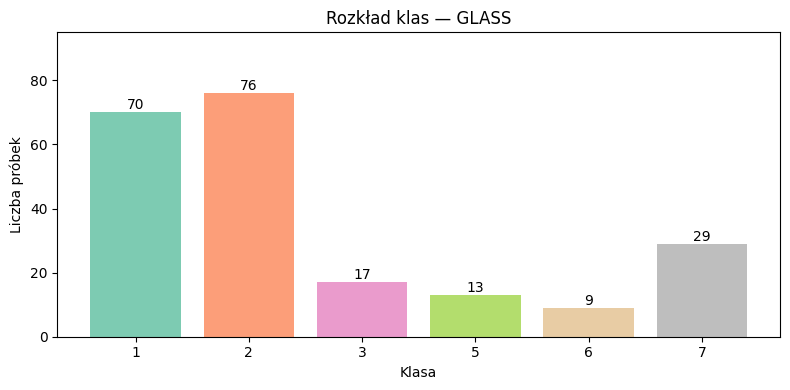

In [101]:
vc = pd.Series(y_glass).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
colors = plt.cm.Set2(np.linspace(0, 1, len(vc)))
bars = ax.bar(vc.index.astype(str), vc.values, color=colors, alpha=0.85)
for bar, cnt in zip(bars, vc.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(cnt), ha='center', fontsize=10)
ax.set_title('Rozkład klas — GLASS')
ax.set_ylabel('Liczba próbek')
ax.set_xlabel('Klasa')
ax.set_ylim(0, max(vc.values) * 1.25)
plt.tight_layout()
plt.show()

In [102]:
X_train, X_test, y_train, y_test = train_test_split(
    X_glass.values, y_glass, test_size=0.2, stratify=y_glass
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Rozkład klas train: {np.bincount(y_train)}')
print(f'Rozkład klas test:  {np.bincount(y_test)}')

Train: (171, 9), Test: (43, 9)
Rozkład klas train: [ 0 56 61 14  0 10  7 23]
Rozkład klas test:  [ 0 14 15  3  0  3  2  6]


## 2. Drzewo decyzyjne — domyślne parametry

In [103]:
from sklearn.metrics import classification_report

def eval_clf(clf, X_train, y_train, X_test, y_test, avg='macro'):
    if not hasattr(clf, 'classes_'):
        clf.fit(X_train, y_train)
    
    yp_tr = clf.predict(X_train)
    yp_te = clf.predict(X_test)
    
    print(f'Głębokość: {clf.get_depth()}, Liście: {clf.get_n_leaves()}')
    print()
    
    metrics = {'Accuracy': accuracy_score, 'Precision': precision_score,
               'Recall': recall_score, 'F1': f1_score}
    
    print(f'{"Metryka":<12} {"Train":>8} {"Test":>8}')
    print('-' * 30)
    for name, fn in metrics.items():
        kw = {} if name == 'Accuracy' else {'average': avg, 'zero_division': 0}
        print(f'{name:<12} {fn(y_train, yp_tr, **kw):>8.4f} {fn(y_test, yp_te, **kw):>8.4f}')
    
    return yp_te

In [104]:
clf_default = DecisionTreeClassifier()
clf_default.fit(X_train, y_train)
y_test_pred = eval_clf(clf_default, X_train, y_train, X_test, y_test)

Głębokość: 12, Liście: 46

Metryka         Train     Test
------------------------------
Accuracy       1.0000   0.7674
Precision      1.0000   0.7893
Recall         1.0000   0.7373
F1             1.0000   0.7350


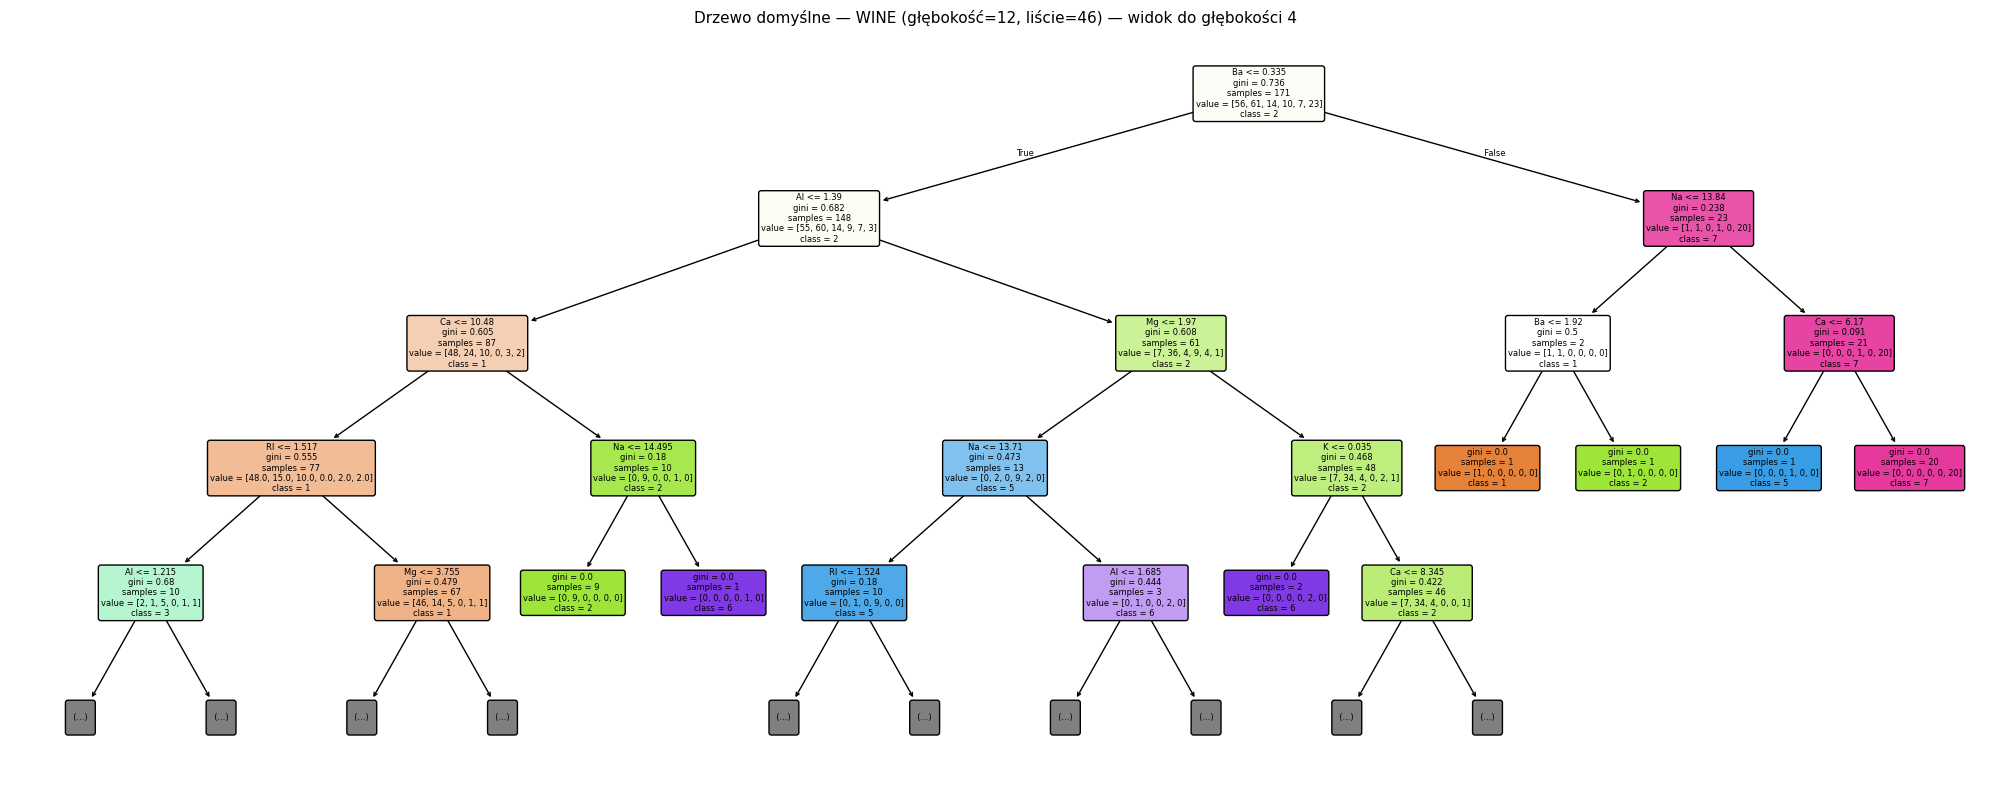

Reprezentacja tekstowa (pierwsze 3 poziomy):
|--- Ba <= 0.34
|   |--- Al <= 1.39
|   |   |--- Ca <= 10.48
|   |   |   |--- RI <= 1.52
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- RI >  1.52
|   |   |   |   |--- truncated branch of depth 9
|   |   |--- Ca >  10.48
|   |   |   |--- Na <= 14.50
|   |   |   |   |--- class: 2
|   |   |   |--- Na >  14.50
|   |   |   |   |--- class: 6
|   |--- Al >  1.39
|   |   |--- Mg <= 1.97
|   |   |   |--- Na <= 13.71
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- Na >  13.71
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- Mg >  1.97
|   |   |   |--- K <= 0.04
|   |   |   |   |--- class: 6
|   |   |   |--- K >  0.04
|   |   |   |   |--- truncated branch of depth 5
|--- Ba >  0.34
|   |--- Na <= 13.84
|   |   |--- Ba <= 1.92
|   |   |   |--- class: 1
|   |   |--- Ba >  1.92
|   |   |   |--- class: 2
|   |--- Na >  13.84
|   |   |--- Ca <= 6.17
|   |   |   |--- class: 5
|   |   |--- Ca >  6.17
|   |   

In [105]:
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(clf_default,
          feature_names=feature_names,
          class_names=class_names,
          filled=True, rounded=True, fontsize=6, max_depth=4, ax=ax)
depth  = clf_default.get_depth()
leaves = clf_default.get_n_leaves()
ax.set_title(
    f'Drzewo domyślne — WINE (głębokość={depth}, liście={leaves}) — widok do głębokości 4',
    fontsize=11
)
plt.tight_layout()
plt.show()

print('Reprezentacja tekstowa (pierwsze 3 poziomy):')
print(export_text(clf_default, feature_names=feature_names, max_depth=3))

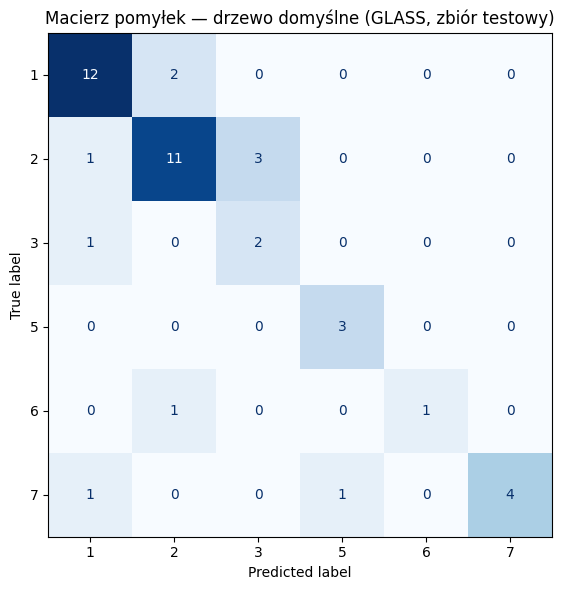

In [106]:
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Macierz pomyłek — drzewo domyślne (GLASS, zbiór testowy)')
plt.tight_layout()
plt.show()

## 3. Strojenie hiperparametrów

### 3.1 `max_depth` — ograniczenie głębokości

max_depth sweep:   0%|          | 0/14 [00:00<?, ?it/s]

Drzewo nasycone przy max_depth=13 (rzeczywista głębokość=12), przerywam sweep.
Najlepsza głębokość (wg CV): max_depth=8, CV acc=0.6660


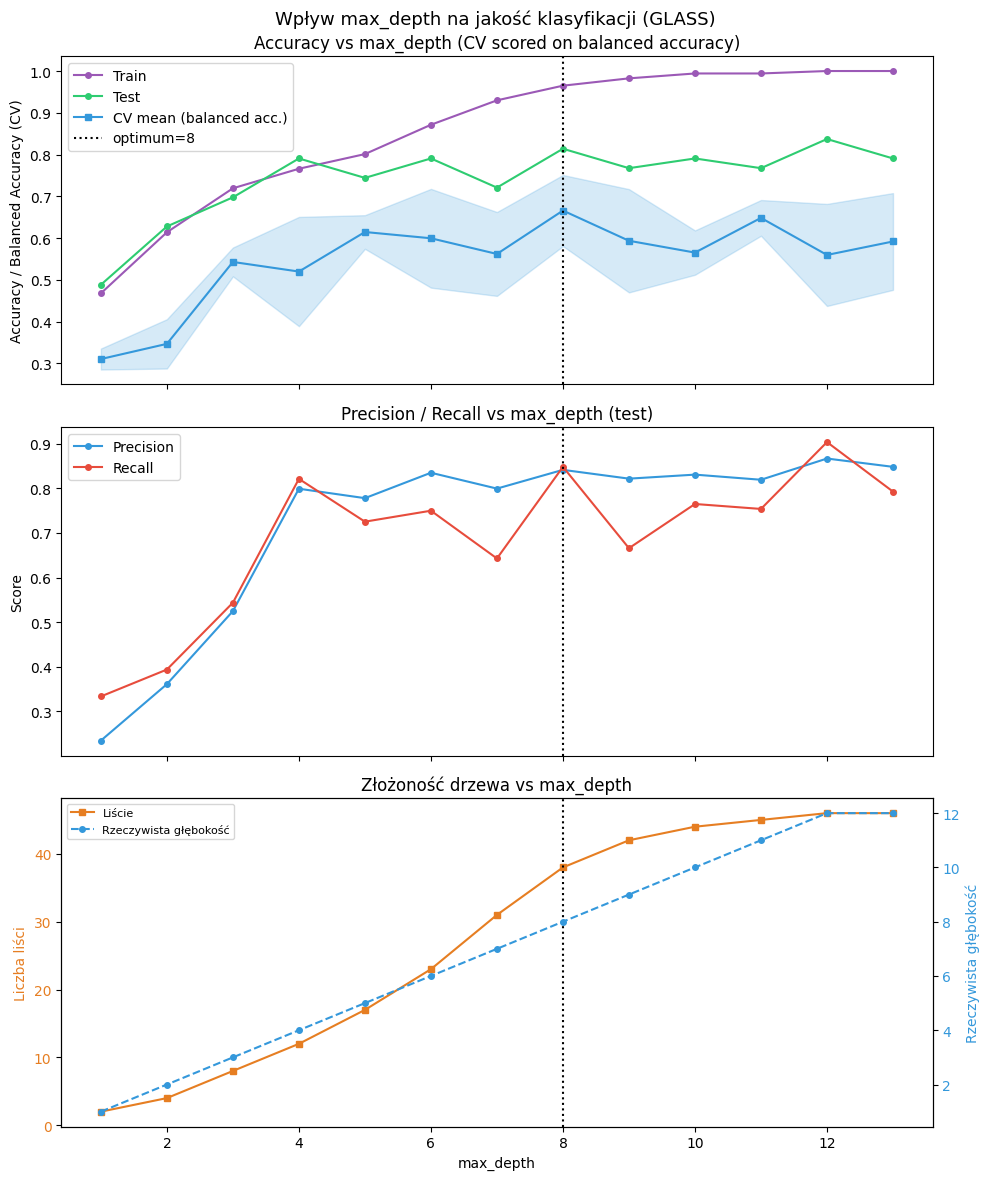

In [107]:
depths = list(range(1, 15))
depth_results = []

skf = StratifiedKFold(n_splits=5, shuffle=True)

for d in tqdm(depths, desc='max_depth sweep'):
    clf = DecisionTreeClassifier(max_depth=d)
    clf.fit(X_train, y_train)
    yp_tr = clf.predict(X_train)
    yp_te = clf.predict(X_test)
    cv_scores = cross_val_score(clf, X_train, y_train, cv=skf, scoring='balanced_accuracy')
    
    actual_depth = clf.get_depth()
    depth_results.append({
        'max_depth':    d,
        'actual_depth': actual_depth,
        'train_acc':    accuracy_score(y_train, yp_tr),
        'test_acc':     accuracy_score(y_test, yp_te),
        'cv_mean':      cv_scores.mean(),
        'cv_std':       cv_scores.std(),
        'test_prec':    precision_score(y_test, yp_te, average='macro', zero_division=0),
        'test_rec':     recall_score(y_test, yp_te, average='macro', zero_division=0),
        'n_leaves':     clf.get_n_leaves(),
    })
    
    if actual_depth < d:
        print(f'Drzewo nasycone przy max_depth={d} (rzeczywista głębokość={actual_depth}), przerywam sweep.')
        break

df_depth = pd.DataFrame(depth_results).set_index('max_depth')
best_depth = int(df_depth['cv_mean'].idxmax())
print(f'Najlepsza głębokość (wg CV): max_depth={best_depth}, CV acc={df_depth.loc[best_depth, "cv_mean"]:.4f}')

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# 1) Accuracy: train / test / CV
axes[0].plot(df_depth.index, df_depth['train_acc'], color='#9b59b6', marker='o', markersize=4, label='Train')
axes[0].plot(df_depth.index, df_depth['test_acc'],  color='#2ecc71', marker='o', markersize=4, label='Test')
axes[0].plot(df_depth.index, df_depth['cv_mean'],   color='#3498db', marker='s', markersize=4, label='CV mean (balanced acc.)')
axes[0].fill_between(df_depth.index,
                     df_depth['cv_mean'] - df_depth['cv_std'],
                     df_depth['cv_mean'] + df_depth['cv_std'],
                     alpha=0.2, color='#3498db')
axes[0].axvline(best_depth, color='black', linestyle=':', label=f'optimum={best_depth}')
axes[0].set_ylabel('Accuracy / Balanced Accuracy (CV)')
axes[0].set_title('Accuracy vs max_depth (CV scored on balanced accuracy)')
axes[0].legend()

# 2) Precision / Recall
axes[1].plot(df_depth.index, df_depth['test_prec'], color='#3498db', marker='o', markersize=4, label='Precision')
axes[1].plot(df_depth.index, df_depth['test_rec'],  color='#e74c3c', marker='o', markersize=4, label='Recall')
axes[1].axvline(best_depth, color='black', linestyle=':')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision / Recall vs max_depth (test)')
axes[1].legend()

# 3) Złożoność + rzeczywista głębokość
axes[2].plot(df_depth.index, df_depth['n_leaves'], color='#e67e22', marker='s', markersize=4, label='Liście')
axes[2].axvline(best_depth, color='black', linestyle=':')
axes[2].set_ylabel('Liczba liści', color='#e67e22')
axes[2].tick_params(axis='y', labelcolor='#e67e22')
axes[2].set_xlabel('max_depth')
axes[2].set_title('Złożoność drzewa vs max_depth')

ax_act = axes[2].twinx()
ax_act.plot(df_depth.index, df_depth['actual_depth'], color='#3498db', marker='o', markersize=4, linestyle='--', label='Rzeczywista głębokość')
ax_act.set_ylabel('Rzeczywista głębokość', color='#3498db')
ax_act.tick_params(axis='y', labelcolor='#3498db')

lines1, labels1 = axes[2].get_legend_handles_labels()
lines2, labels2 = ax_act.get_legend_handles_labels()
axes[2].legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.suptitle('Wpływ max_depth na jakość klasyfikacji (GLASS)', fontsize=13)
plt.tight_layout()
plt.show()

### 3.2 `min_samples_leaf` — minimalna liczba próbek w liściu



min_samples_leaf sweep:   0%|          | 0/30 [00:00<?, ?it/s]

Najlepsze min_samples_leaf (wg CV): 5, CV acc=0.6178


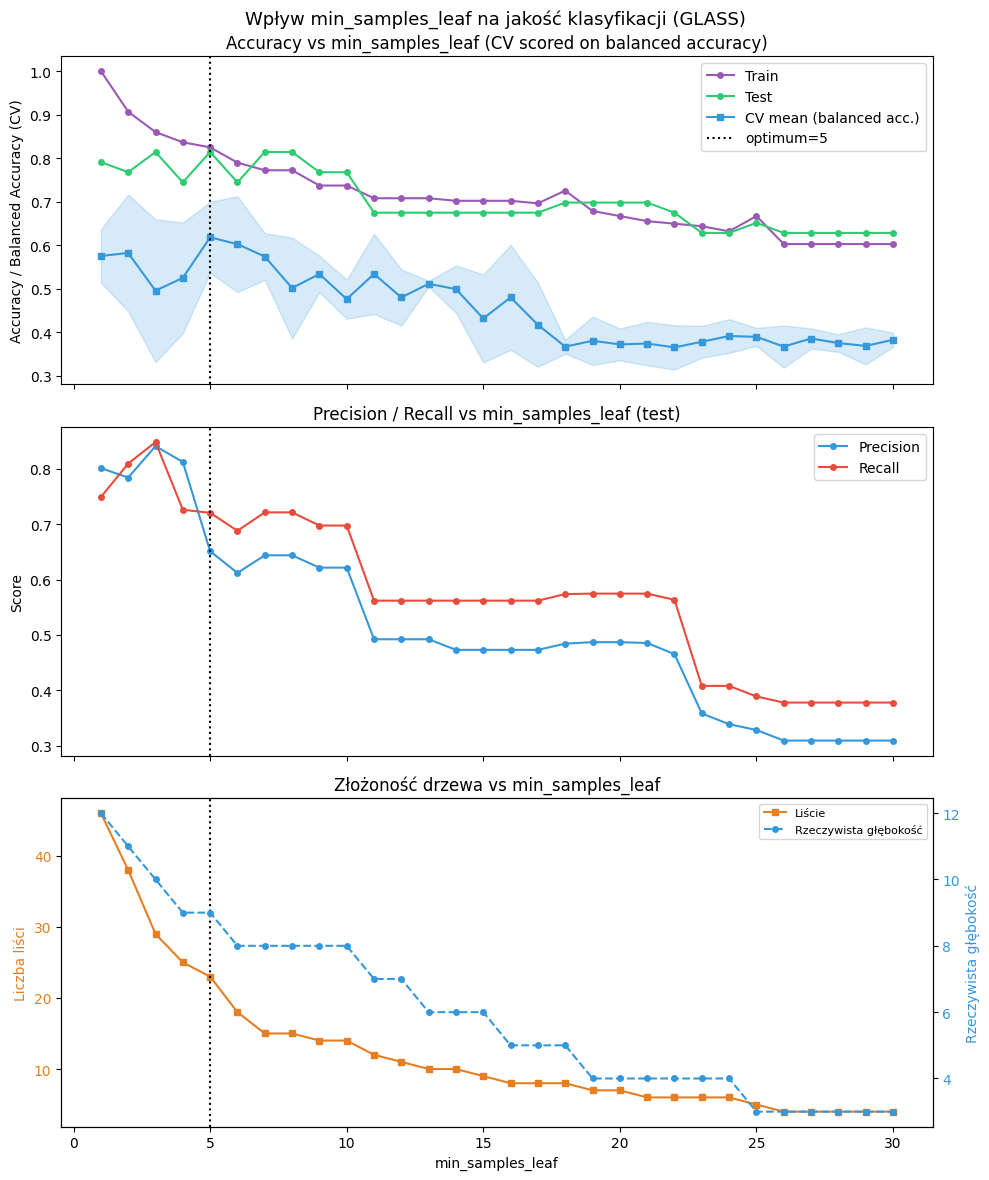

In [108]:
min_samples_values = list(range(1, 31))
leaf_results = []

skf = StratifiedKFold(n_splits=5, shuffle=True)

for ms in tqdm(min_samples_values, desc='min_samples_leaf sweep'):
    clf = DecisionTreeClassifier(min_samples_leaf=ms)
    clf.fit(X_train, y_train)
    yp_tr = clf.predict(X_train)
    yp_te = clf.predict(X_test)
    cv_scores = cross_val_score(clf, X_train, y_train, cv=skf, scoring='balanced_accuracy')
    
    leaf_results.append({
        'min_samples_leaf': ms,
        'actual_depth': clf.get_depth(),
        'train_acc':    accuracy_score(y_train, yp_tr),
        'test_acc':     accuracy_score(y_test, yp_te),
        'cv_mean':      cv_scores.mean(),
        'cv_std':       cv_scores.std(),
        'test_prec':    precision_score(y_test, yp_te, average='macro', zero_division=0),
        'test_rec':     recall_score(y_test, yp_te, average='macro', zero_division=0),
        'n_leaves':     clf.get_n_leaves(),
    })

df_leaf = pd.DataFrame(leaf_results).set_index('min_samples_leaf')
best_ms = int(df_leaf['cv_mean'].idxmax())
print(f'Najlepsze min_samples_leaf (wg CV): {best_ms}, CV acc={df_leaf.loc[best_ms, "cv_mean"]:.4f}')

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

axes[0].plot(df_leaf.index, df_leaf['train_acc'], color='#9b59b6', marker='o', markersize=4, label='Train')
axes[0].plot(df_leaf.index, df_leaf['test_acc'],  color='#2ecc71', marker='o', markersize=4, label='Test')
axes[0].plot(df_leaf.index, df_leaf['cv_mean'],   color='#3498db', marker='s', markersize=4, label='CV mean (balanced acc.)')
axes[0].fill_between(df_leaf.index,
                     df_leaf['cv_mean'] - df_leaf['cv_std'],
                     df_leaf['cv_mean'] + df_leaf['cv_std'],
                     alpha=0.2, color='#3498db')
axes[0].axvline(best_ms, color='black', linestyle=':', label=f'optimum={best_ms}')
axes[0].set_ylabel('Accuracy / Balanced Accuracy (CV)')
axes[0].set_title('Accuracy vs min_samples_leaf (CV scored on balanced accuracy)')
axes[0].legend()

axes[1].plot(df_leaf.index, df_leaf['test_prec'], color='#3498db', marker='o', markersize=4, label='Precision')
axes[1].plot(df_leaf.index, df_leaf['test_rec'],  color='#e74c3c', marker='o', markersize=4, label='Recall')
axes[1].axvline(best_ms, color='black', linestyle=':')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision / Recall vs min_samples_leaf (test)')
axes[1].legend()

axes[2].plot(df_leaf.index, df_leaf['n_leaves'], color='#e67e22', marker='s', markersize=4, label='Liście')
axes[2].axvline(best_ms, color='black', linestyle=':')
axes[2].set_ylabel('Liczba liści', color='#e67e22')
axes[2].tick_params(axis='y', labelcolor='#e67e22')
axes[2].set_xlabel('min_samples_leaf')
axes[2].set_title('Złożoność drzewa vs min_samples_leaf')

ax_act = axes[2].twinx()
ax_act.plot(df_leaf.index, df_leaf['actual_depth'], color='#3498db', marker='o', markersize=4, linestyle='--', label='Rzeczywista głębokość')
ax_act.set_ylabel('Rzeczywista głębokość', color='#3498db')
ax_act.tick_params(axis='y', labelcolor='#3498db')

lines1, labels1 = axes[2].get_legend_handles_labels()
lines2, labels2 = ax_act.get_legend_handles_labels()
axes[2].legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.suptitle('Wpływ min_samples_leaf na jakość klasyfikacji (GLASS)', fontsize=13)
plt.tight_layout()
plt.show()

### 3.3 Przycinanie drzewa — `ccp_alpha` (Cost-Complexity Pruning)

Liczba kroków pruning path: 35
Zakres ccp_alpha: [0.000000, 0.066043]


ccp_alpha sweep:   0%|          | 0/35 [00:00<?, ?it/s]

Najlepsza ccp_alpha (wg CV): 0.009357, CV acc=0.6762
Wynikowe drzewo: głębokość=8, liście=25


([<matplotlib.lines.Line2D at 0x12304fef0>],)

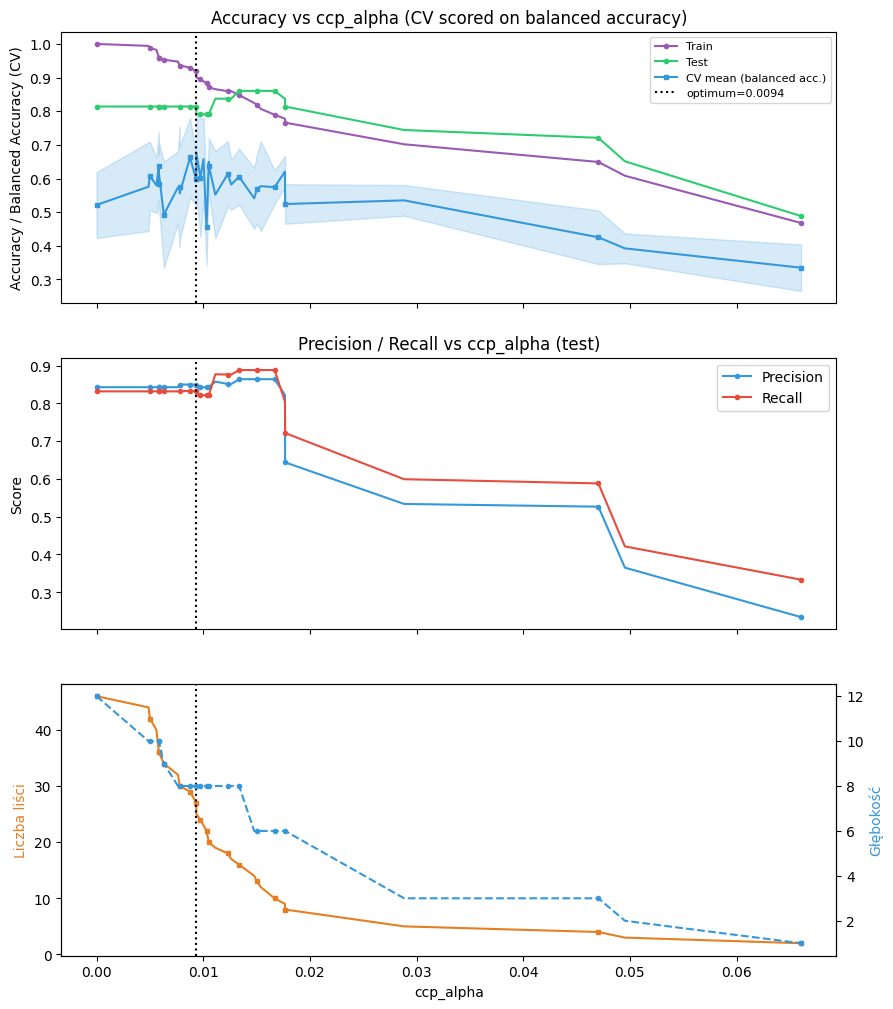

In [ ]:
path = DecisionTreeClassifier().cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[:-1]

skf = StratifiedKFold(n_splits=5, shuffle=True)

print(f'Liczba kroków pruning path: {len(ccp_alphas)}')
print(f'Zakres ccp_alpha: [{ccp_alphas.min():.6f}, {ccp_alphas.max():.6f}]')

alpha_results = []
for alpha in tqdm(ccp_alphas, desc='ccp_alpha sweep'):
    clf = DecisionTreeClassifier(ccp_alpha=alpha)
    clf.fit(X_train, y_train)
    yp_tr = clf.predict(X_train)
    yp_te = clf.predict(X_test)
    cv_scores = cross_val_score(clf, X_train, y_train, cv=skf, scoring='balanced_accuracy')
    
    alpha_results.append({
        'ccp_alpha': alpha,
        'train_acc': accuracy_score(y_train, yp_tr),
        'test_acc':  accuracy_score(y_test, yp_te),
        'cv_mean':   cv_scores.mean(),
        'cv_std':    cv_scores.std(),
        'test_prec': precision_score(y_test, yp_te, average='macro', zero_division=0),
        'test_rec':  recall_score(y_test, yp_te, average='macro', zero_division=0),
        'n_leaves':  clf.get_n_leaves(),
        'depth':     clf.get_depth(),
    })

df_alpha = pd.DataFrame(alpha_results)
best_alpha_idx = df_alpha['cv_mean'].idxmax()
best_row       = df_alpha.loc[best_alpha_idx]
best_alpha     = float(best_row['ccp_alpha'])

print(f'Najlepsza ccp_alpha (wg CV): {best_alpha:.6f}, CV acc={best_row["cv_mean"]:.4f}')
print(f'Wynikowe drzewo: głębokość={int(best_row["depth"])}, liście={int(best_row["n_leaves"])}')

n_points  = len(df_alpha)
markevery = max(1, n_points // 15)  # max ~15 kropek na wykresie

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# 1) Accuracy
axes[0].plot(df_alpha['ccp_alpha'], df_alpha['train_acc'], color='#9b59b6', linewidth=1.5, marker='o', markersize=3, markevery=markevery, label='Train')
axes[0].plot(df_alpha['ccp_alpha'], df_alpha['test_acc'],  color='#2ecc71', linewidth=1.5, marker='o', markersize=3, markevery=markevery, label='Test')
axes[0].plot(df_alpha['ccp_alpha'], df_alpha['cv_mean'],   color='#3498db', linewidth=1.5, marker='s', markersize=3, markevery=markevery, label='CV mean (balanced acc.)')
axes[0].fill_between(df_alpha['ccp_alpha'],
                     df_alpha['cv_mean'] - df_alpha['cv_std'],
                     df_alpha['cv_mean'] + df_alpha['cv_std'],
                     alpha=0.2, color='#3498db')
axes[0].axvline(best_alpha, color='black', linestyle=':', label=f'optimum={best_alpha:.4f}')
axes[0].set_ylabel('Accuracy / Balanced Accuracy (CV)')
axes[0].set_title('Accuracy vs ccp_alpha (CV scored on balanced accuracy)')
axes[0].legend(fontsize=8)

# 2) Precision / Recall
axes[1].plot(df_alpha['ccp_alpha'], df_alpha['test_prec'], color='#3498db', linewidth=1.5, marker='o', markersize=3, markevery=markevery, label='Precision')
axes[1].plot(df_alpha['ccp_alpha'], df_alpha['test_rec'],  color='#e74c3c', linewidth=1.5, marker='o', markersize=3, markevery=markevery, label='Recall')
axes[1].axvline(best_alpha, color='black', linestyle=':')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision / Recall vs ccp_alpha (test)')
axes[1].legend()

# 3) Rozmiar drzewa — liście + głębokość na dwóch osiach
ax_leaves = axes[2]
ax_depth  = ax_leaves.twinx()
ax_leaves.plot(df_alpha['ccp_alpha'], df_alpha['n_leaves'], color='#e67e22', linewidth=1.5, marker='s', markersize=3, markevery=markevery, label='Liście')
ax_depth.plot(df_alpha['ccp_alpha'], df_alpha['depth'],     color='#3498db', linewidth=1.5, marker='o', markersize=3, markevery=markevery, linestyle='--', label='Głębokość')
ax_leaves.axvline(best_alpha, color='black', linestyle=':')
ax_leaves.set_xlabel('ccp_alpha')
ax_leaves.set_ylabel('Liczba liści', color='#e67e22')
ax_depth.set_ylabel('Głębokość', color='#3498db')
lines1, labels1 = ax_leaves.get_legend_handles_labels()
lines2,

### 3.4 GridSearchCV — automatyczne strojenie

GridSearchCV z `StratifiedKFold(n_splits=5)` przeszukuje przestrzeń hiperparametrów i wybiera najlepszy zestaw według `f1_macro`.

In [120]:
path = DecisionTreeClassifier().cost_complexity_pruning_path(X_train, y_train)
ccp_candidates = path.ccp_alphas[:-1]
step = max(1, len(ccp_candidates) // 8)
ccp_grid = [0.0] + list(ccp_candidates[::step])

param_grid = {
    'max_depth':        [3, 4, 5, 6, 7, 8, None],
    'min_samples_leaf': [1, 2, 3, 5, 10, 15, 20],
    'ccp_alpha':        ccp_grid,
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(),
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True),
    scoring='balanced_accuracy',
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

print(f'Najlepsze parametry:       {grid_search.best_params_}')
print(f'Najlepsza balanced acc CV: {grid_search.best_score_:.4f}')

clf_best    = grid_search.best_estimator_
y_best_pred = clf_best.predict(X_test)

print()
print(f'{"Metryka":<15} {"Test":>8}')
print('-' * 25)
for name, val in [
    ('Accuracy',  accuracy_score(y_test,  y_best_pred)),
    ('Precision', precision_score(y_test, y_best_pred, average='macro', zero_division=0)),
    ('Recall',    recall_score(y_test,    y_best_pred, average='macro', zero_division=0)),
]:
    print(f'{name:<15} {val:>8.4f}')
print(f'Głębokość: {clf_best.get_depth()}, Liście: {clf_best.get_n_leaves()}')

Najlepsze parametry:       {'ccp_alpha': np.float64(0.005847953216374269), 'max_depth': 7, 'min_samples_leaf': 1}
Najlepsza balanced acc CV: 0.6512

Metryka             Test
-------------------------
Accuracy          0.7674
Precision         0.8222
Recall            0.7373
Głębokość: 7, Liście: 28


,Accuracy,Precision,Recall,Głębokość,Liście
Model,,,,,
Default,0.8605,0.8806,0.9159,12,46
max_depth=8,0.7674,0.7882,0.7373,8,38
min_samples_leaf=5,0.8140,0.6512,0.7206,9,23
ccp_alpha=0.0094,0.8140,0.8497,0.8492,8,25
GridSearch,0.7907,0.8275,0.8365,7,28


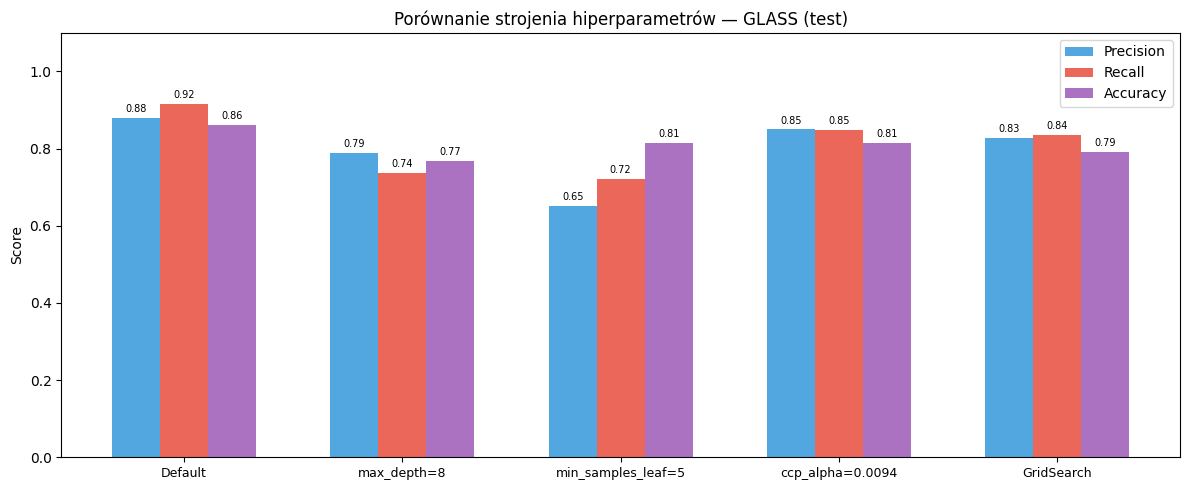

In [141]:
from sklearn.base import clone

# najlepsze wartości z wcześniejszych sweepów
best_alpha = float(df_alpha.loc[df_alpha['cv_mean'].idxmax(), 'ccp_alpha'])

configs = [
    ('Default',                        DecisionTreeClassifier()),
    (f'max_depth={best_depth}',        DecisionTreeClassifier(max_depth=best_depth)),
    (f'min_samples_leaf={best_ms}',    DecisionTreeClassifier(min_samples_leaf=best_ms)),
    (f'ccp_alpha={best_alpha:.4f}',    DecisionTreeClassifier(ccp_alpha=best_alpha)),
    ('GridSearch',                     clone(grid_search.best_estimator_)),
]

compare_results = []
for name, clf in configs:
    clf.fit(X_train, y_train)
    yp = clf.predict(X_test)
    compare_results.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, yp),
        'Precision': precision_score(y_test, yp, average='macro', zero_division=0),
        'Recall':    recall_score(y_test, yp, average='macro', zero_division=0),
        'Głębokość': clf.get_depth(),
        'Liście':    clf.get_n_leaves(),
    })

df_compare = pd.DataFrame(compare_results).set_index('Model')
display(df_compare.round(4))

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(df_compare))
width = 0.22
metrics_colors = [('Precision', '#3498db'), ('Recall', '#e74c3c'), ('Accuracy', '#9b59b6')]
offsets = [-1, 0, 1]

for (metric, color), offset in zip(metrics_colors, offsets):
    bars = ax.bar(x + offset * width, df_compare[metric], width, label=metric, color=color, alpha=0.85)
    for bar in bars:
        if bar.get_height() > 0.02:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(df_compare.index, fontsize=9)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_title('Porównanie strojenia hiperparametrów — GLASS (test)')
ax.legend()
plt.tight_layout()
plt.show()

### 3.5 Wizualizacja wybranych drzew

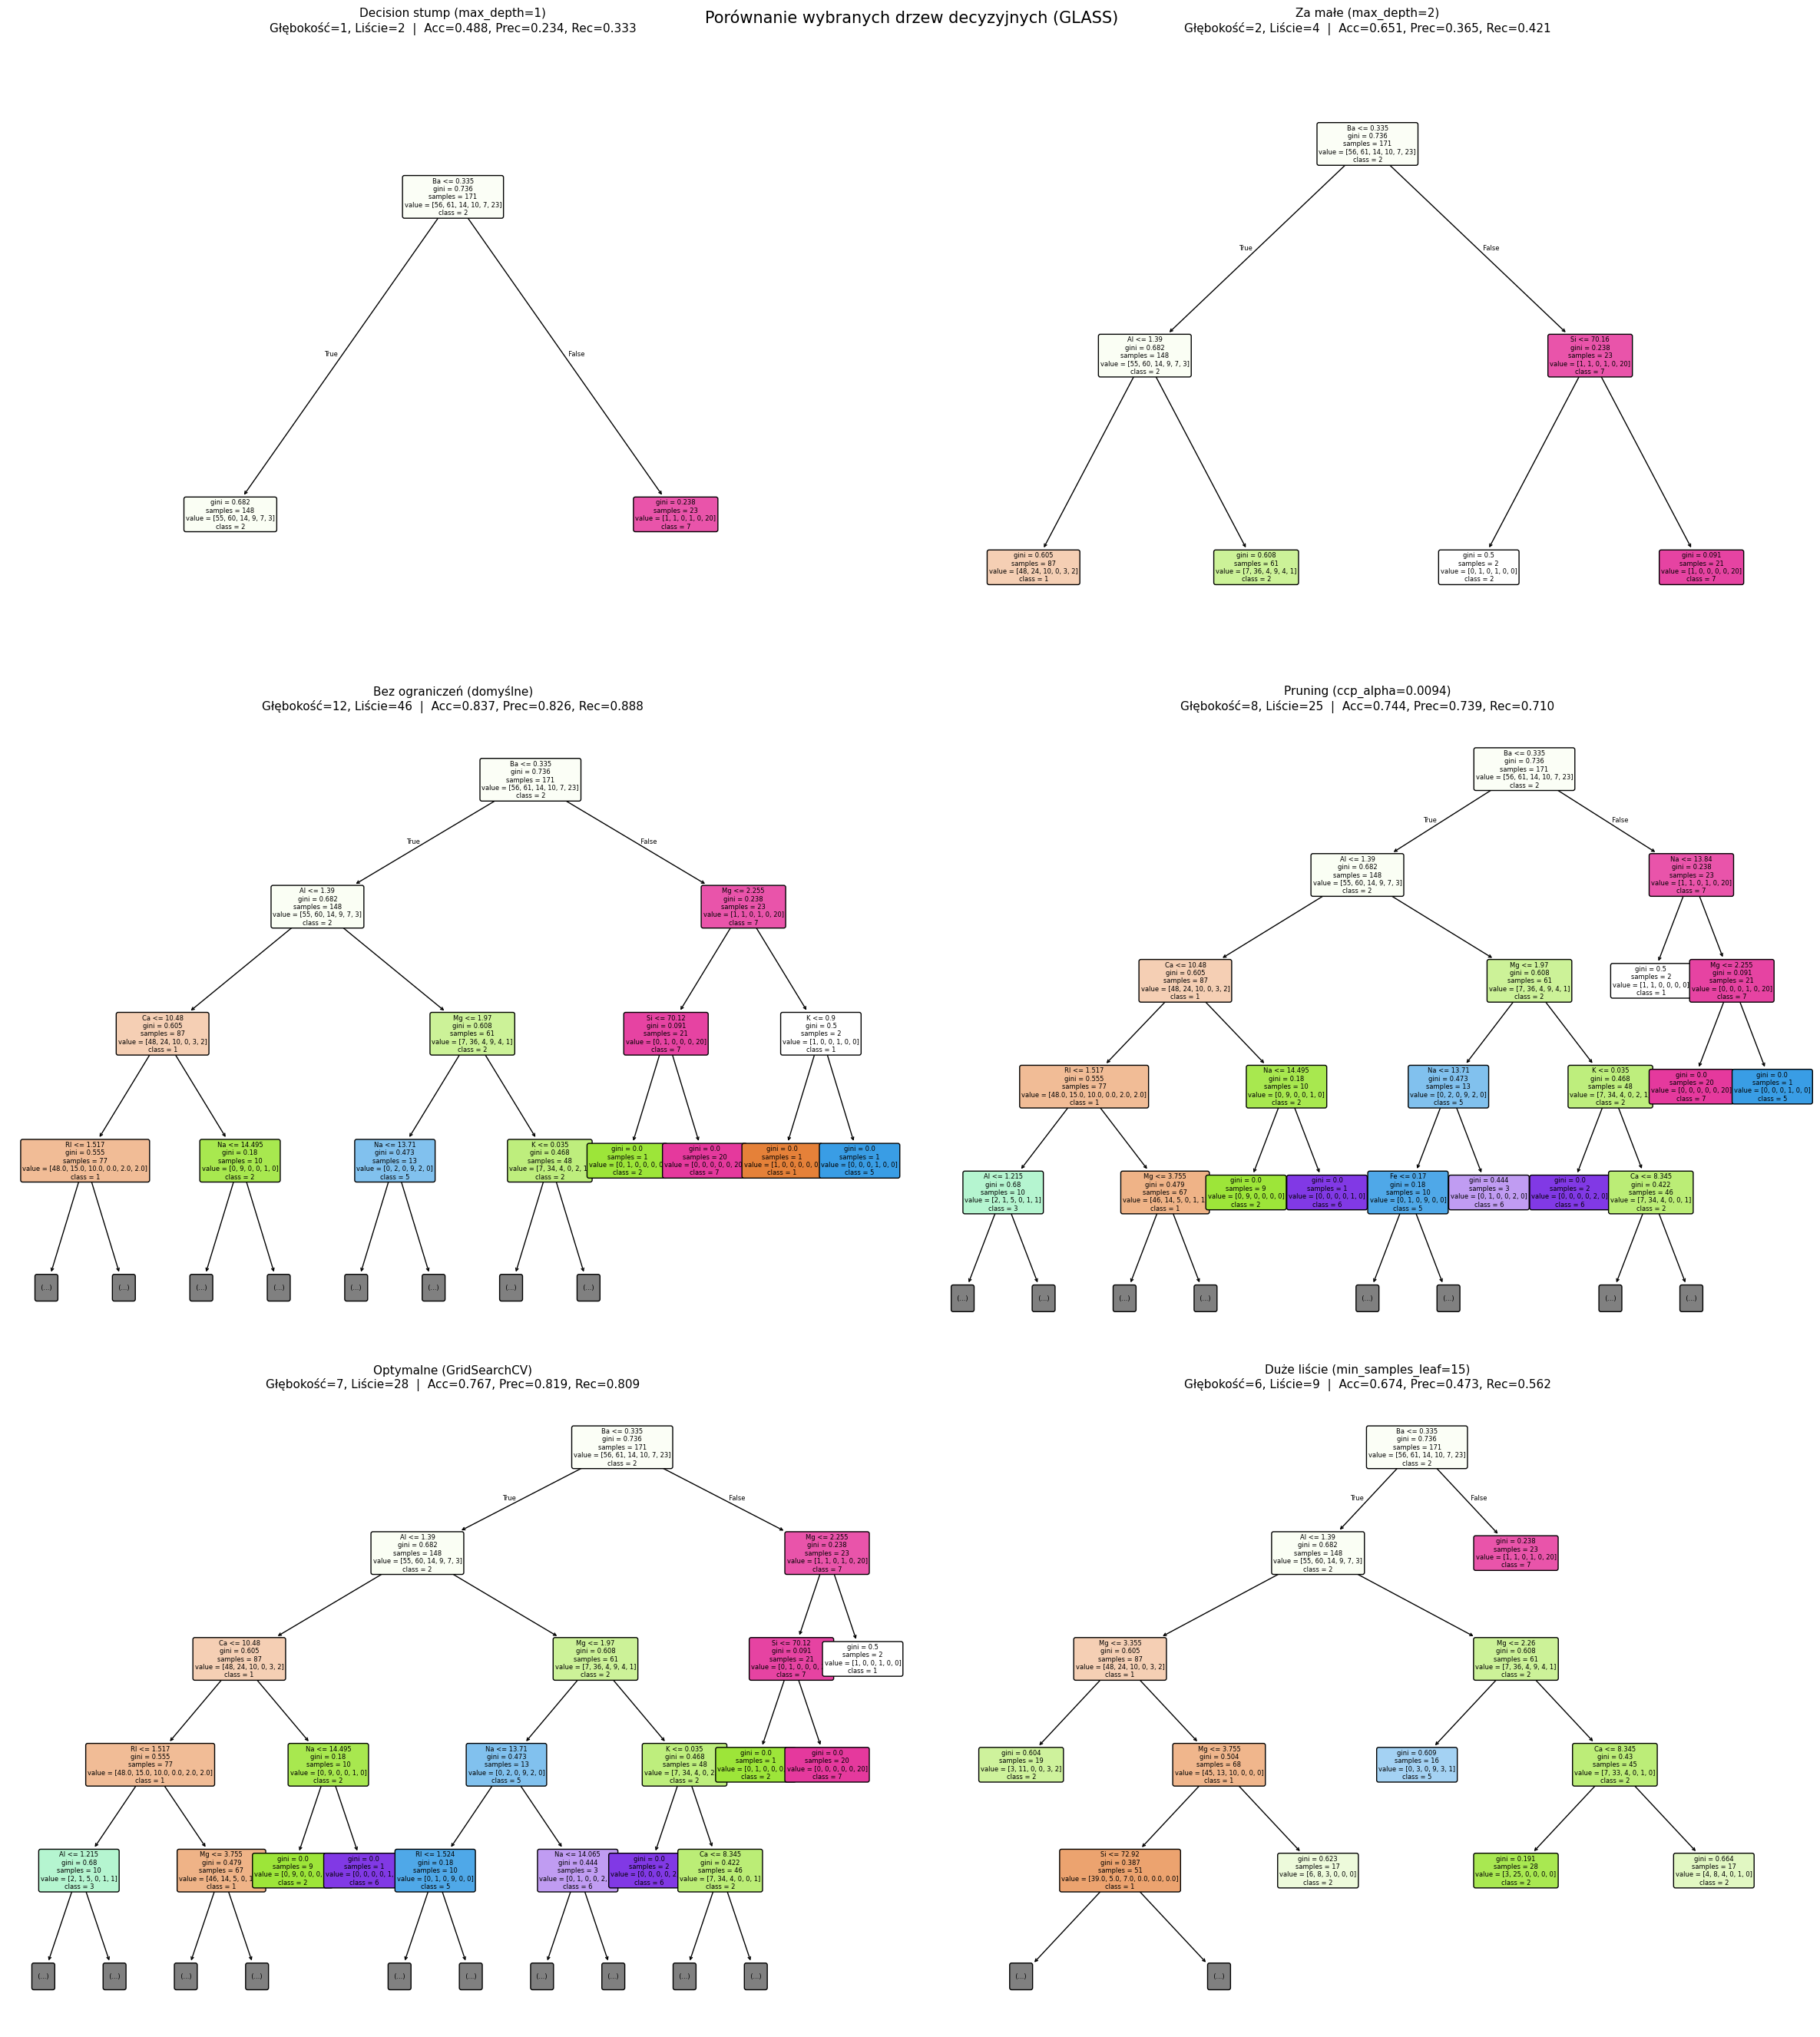

In [145]:
from sklearn.base import clone

tree_variants = [
    ('Decision stump (max_depth=1)',          DecisionTreeClassifier(max_depth=1),                2),
    ('Za małe (max_depth=2)',                 DecisionTreeClassifier(max_depth=2),                3),
    ('Bez ograniczeń (domyślne)',             DecisionTreeClassifier(),                           3),
    (f'Pruning (ccp_alpha={best_alpha:.4f})', DecisionTreeClassifier(ccp_alpha=best_alpha),       4),
    ('Optymalne (GridSearchCV)',              clone(grid_search.best_estimator_),                 4),
    ('Duże liście (min_samples_leaf=15)',     DecisionTreeClassifier(min_samples_leaf=15),        4),
]

fig, axes = plt.subplots(3, 2, figsize=(24, 27))

for ax, (title, clf, show_depth) in zip(axes.flatten(), tree_variants):
    clf.fit(X_train, y_train)
    yp   = clf.predict(X_test)
    acc  = accuracy_score(y_test, yp)
    prec = precision_score(y_test, yp, average='macro', zero_division=0)
    rec  = recall_score(y_test, yp, average='macro', zero_division=0)
    d    = clf.get_depth()
    nl   = clf.get_n_leaves()
    plot_tree(clf, feature_names=feature_names, class_names=class_names,
              filled=True, rounded=True, fontsize=6, max_depth=show_depth, ax=ax)
    ax.set_title(
        f'{title}\nGłębokość={d}, Liście={nl}  |  Acc={acc:.3f}, Prec={prec:.3f}, Rec={rec:.3f}',
        fontsize=11
    )

plt.suptitle('Porównanie wybranych drzew decyzyjnych (GLASS)', fontsize=15)
plt.tight_layout()
plt.show()

### 3.6 Ważność cech (Feature Importance)

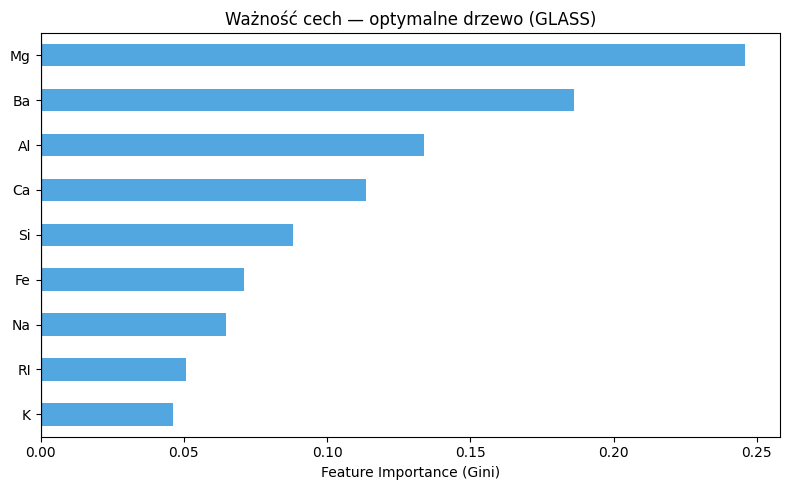

Top cechy (malejąco):
  Mg                             0.2458
  Ba                             0.1861
  Al                             0.1340
  Ca                             0.1134
  Si                             0.0881
  Fe                             0.0712
  Na                             0.0647
  RI                             0.0506
  K                              0.0461


In [146]:
imp_df = pd.Series(clf_best.feature_importances_, index=feature_names).sort_values()
imp_df = imp_df[imp_df > 0]

fig, ax = plt.subplots(figsize=(8, 5))
imp_df.plot.barh(ax=ax, color='#3498db', alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Ważność cech — optymalne drzewo (GLASS)')
ax.set_xlabel('Feature Importance (Gini)')
plt.tight_layout()
plt.show()

print('Top cechy (malejąco):')
for feat, val in imp_df.sort_values(ascending=False).items():
    print(f'  {feat:<30} {val:.4f}')

## 4. Walidacja krzyżowa: zwykła vs stratyfikowana

**KFold** losowo dzieli dane na foldy bez zachowania proporcji klas.  
**StratifiedKFold** gwarantuje, że każdy fold ma podobną proporcję klas jak cały zbiór — szczególnie ważne przy niezbalansowanych zbiorach.

Metoda                     Mean      Std  Wyniki foldów
------------------------------------------------------------------------
KFold                    0.6018   0.0426  [0.6038 0.5659 0.668  0.6237 0.5476]
StratifiedKFold          0.6877   0.1163  [0.7158 0.7067 0.8595 0.6587 0.4976]


/Users/mikolajolesinski/Desktop/uczenie_maszynowe/listy/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/mikolajolesinski/Desktop/uczenie_maszynowe/listy/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


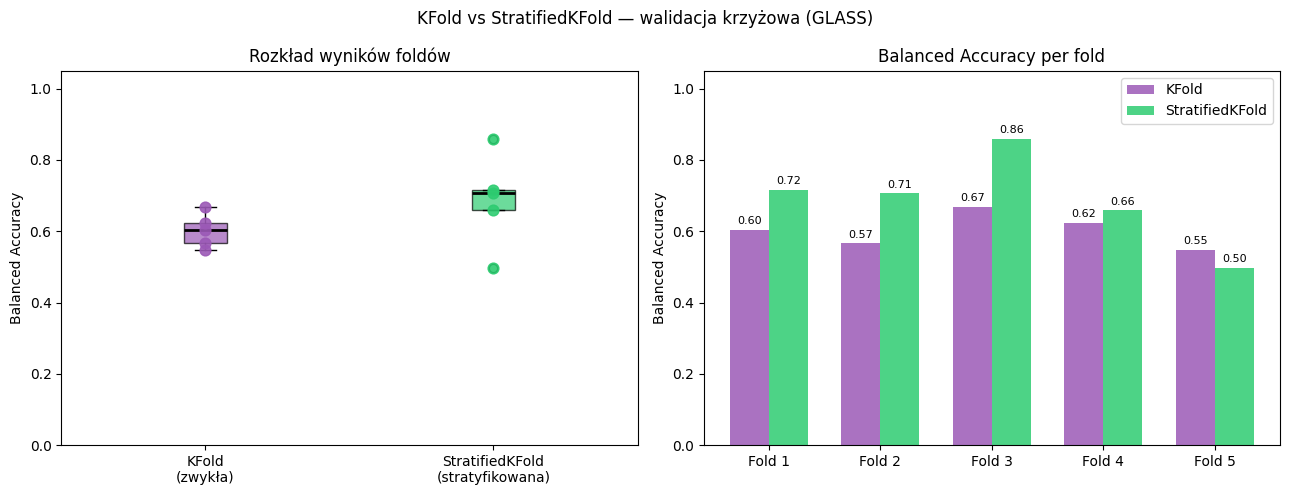

In [154]:
best_params = grid_search.best_params_
clf_cv = DecisionTreeClassifier(
    max_depth=best_params['max_depth'],
    min_samples_leaf=best_params['min_samples_leaf'],
    ccp_alpha=best_params['ccp_alpha'],
)

kf  = KFold(n_splits=5, shuffle=True)
skf = StratifiedKFold(n_splits=5, shuffle=True)

scores_kf  = cross_val_score(clf_cv, X_glass, y_glass, cv=kf,  scoring='balanced_accuracy')
scores_skf = cross_val_score(clf_cv, X_glass, y_glass, cv=skf, scoring='balanced_accuracy')

print(f'{"Metoda":<22} {"Mean":>8} {"Std":>8}  Wyniki foldów')
print('-' * 72)
print(f'{"KFold":<22} {scores_kf.mean():>8.4f} {scores_kf.std():>8.4f}  {np.round(scores_kf, 4)}')
print(f'{"StratifiedKFold":<22} {scores_skf.mean():>8.4f} {scores_skf.std():>8.4f}  {np.round(scores_skf, 4)}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# boxplot z punktami
bp = axes[0].boxplot([scores_kf, scores_skf],
                     tick_labels=['KFold\n(zwykła)', 'StratifiedKFold\n(stratyfikowana)'],
                     patch_artist=True)
for patch, color in zip(bp['boxes'], ['#9b59b6', '#2ecc71']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for med in bp['medians']:
    med.set_color('black')
    med.set_linewidth(2)
axes[0].scatter([1]*len(scores_kf),  scores_kf,  color='#9b59b6', zorder=5, s=60, alpha=0.9)
axes[0].scatter([2]*len(scores_skf), scores_skf, color='#2ecc71', zorder=5, s=60, alpha=0.9)
axes[0].set_title('Rozkład wyników foldów')
axes[0].set_ylabel('Balanced Accuracy')
axes[0].set_ylim(0, 1.05)

# bar per fold
x = np.arange(5)
width = 0.35
fold_labels = [f'Fold {i+1}' for i in range(5)]
bars_kf  = axes[1].bar(x - width/2, scores_kf,  width, color='#9b59b6', alpha=0.85, label='KFold')
bars_skf = axes[1].bar(x + width/2, scores_skf, width, color='#2ecc71', alpha=0.85, label='StratifiedKFold')
for bars in [bars_kf, bars_skf]:
    for bar in bars:
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(fold_labels)
axes[1].set_title('Balanced Accuracy per fold')
axes[1].set_ylabel('Balanced Accuracy')
axes[1].set_ylim(0, 1.05)
axes[1].legend()

plt.suptitle('KFold vs StratifiedKFold — walidacja krzyżowa (GLASS)', fontsize=12)
plt.tight_layout()
plt.show()

/Users/mikolajolesinski/Desktop/uczenie_maszynowe/listy/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/mikolajolesinski/Desktop/uczenie_maszynowe/listy/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/mikolajolesinski/Desktop/uczenie_maszynowe/listy/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/mikolajolesinski/Desktop/uczenie_maszynowe/listy/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/mikolajolesinski/Desktop/uczenie_

KFold: best_alpha=0.011682, CV balanced_acc=0.7096
StratifiedKFold: best_alpha=0.007923, CV balanced_acc=0.7017

--- Globalne metryki (test) ---
Metryka                      KFold    StratifiedKFold
-------------------------------------------------------
Accuracy                    0.7907             0.8140
Precision                   0.8426             0.8497
Recall                      0.8214             0.8325


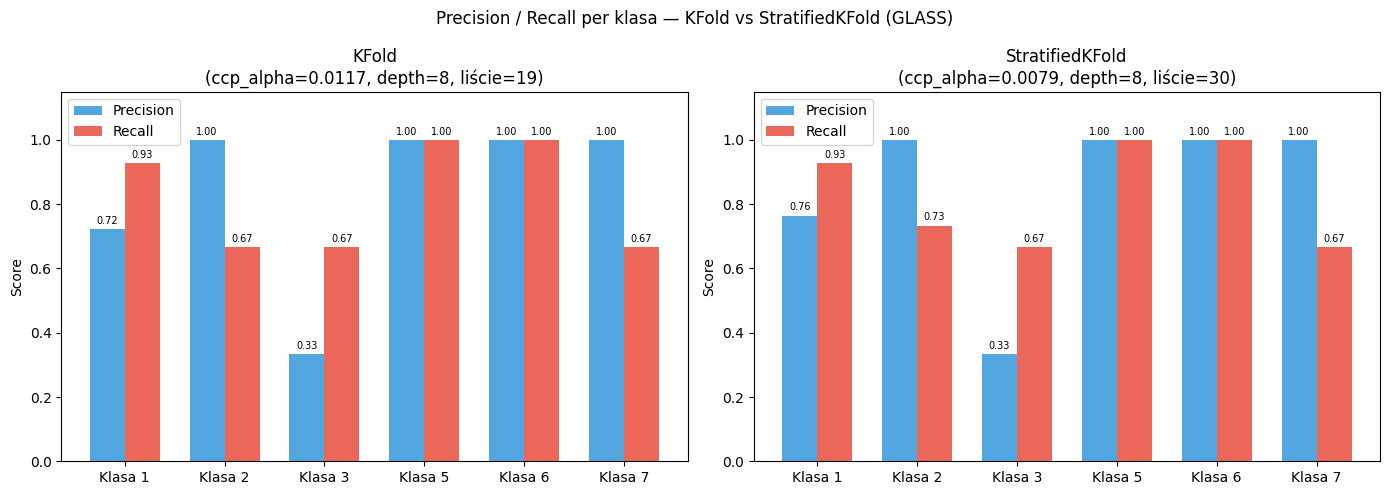

In [156]:
path = DecisionTreeClassifier().cost_complexity_pruning_path(X_glass, y_glass)
ccp_candidates = path.ccp_alphas[:-1]
step = max(1, len(ccp_candidates) // 8)
ccp_grid = [0.0] + list(ccp_candidates[::step])

kf  = KFold(n_splits=5, shuffle=True)
skf = StratifiedKFold(n_splits=5, shuffle=True)

results_per_cv = {}
for cv_name, cv in [('KFold', kf), ('StratifiedKFold', skf)]:
    best_score, best_alpha_cv = -1, 0.0
    for alpha in ccp_grid:
        clf = DecisionTreeClassifier(ccp_alpha=alpha)
        scores = cross_val_score(clf, X_glass, y_glass, cv=cv, scoring='balanced_accuracy')
        if scores.mean() > best_score:
            best_score = scores.mean()
            best_alpha_cv = alpha
    
    clf_final = DecisionTreeClassifier(ccp_alpha=best_alpha_cv)
    clf_final.fit(X_train, y_train)
    yp = clf_final.predict(X_test)
    
    results_per_cv[cv_name] = {
        'best_alpha': best_alpha_cv,
        'cv_score':   best_score,
        'clf':        clf_final,
        'y_pred':     yp,
    }
    print(f'{cv_name}: best_alpha={best_alpha_cv:.6f}, CV balanced_acc={best_score:.4f}')

# --- globalne metryki ---
print('\n--- Globalne metryki (test) ---')
print(f'{"Metryka":<15}', end='')
for cv_name in results_per_cv:
    print(f' {cv_name:>18}', end='')
print()
print('-' * 55)

for metric_name, fn, kw in [
    ('Accuracy',  accuracy_score,  {}),
    ('Precision', precision_score, {'average': 'macro', 'zero_division': 0}),
    ('Recall',    recall_score,    {'average': 'macro', 'zero_division': 0}),
]:
    print(f'{metric_name:<15}', end='')
    for res in results_per_cv.values():
        val = fn(y_test, res['y_pred'], **kw)
        print(f' {val:>18.4f}', end='')
    print()

# --- metryki per klasa ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (cv_name, res) in zip(axes, results_per_cv.items()):
    report = classification_report(y_test, res['y_pred'], output_dict=True, zero_division=0)
    classes = [k for k in report if k not in ('accuracy', 'macro avg', 'weighted avg')]
    
    prec_vals = [report[c]['precision'] for c in classes]
    rec_vals  = [report[c]['recall']    for c in classes]
    
    x = np.arange(len(classes))
    width = 0.35
    bars_p = ax.bar(x - width/2, prec_vals, width, color='#3498db', alpha=0.85, label='Precision')
    bars_r = ax.bar(x + width/2, rec_vals,  width, color='#e74c3c', alpha=0.85, label='Recall')
    
    for bars in [bars_p, bars_r]:
        for bar in bars:
            if bar.get_height() > 0.02:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                        f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)
    
    ax.set_xticks(x)
    ax.set_xticklabels([f'Klasa {c}' for c in classes])
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Score')
    ax.set_title(f'{cv_name}\n(ccp_alpha={res["best_alpha"]:.4f}, depth={res["clf"].get_depth()}, liście={res["clf"].get_n_leaves()})')
    ax.legend()

plt.suptitle('Precision / Recall per klasa — KFold vs StratifiedKFold (GLASS)', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Zbiór Polish Companies Bankruptcy (PCB)


### 5.1 Wczytanie i preprocessing

In [ ]:
print('Wczytywanie Polish Companies Bankruptcy (UCI id=365)...')
dataset = fetch_ucirepo(id=365)
X_raw = dataset.data.features
y_raw = dataset.data.targets

df_pcb = X_raw.copy()
df_pcb['class'] = y_raw['class'].values

print(f'Pełny zbiór: {df_pcb.shape}')
years = sorted(df_pcb['year'].unique())
print(f'Lata: {years}')

df4 = df_pcb[df_pcb['year'] == 4].drop(columns=['year', 'A37'])
feat_cols_pcb = [c for c in df4.columns if c != 'class']
df4 = df4[df4[feat_cols_pcb].isnull().sum(axis=1) <= 7].reset_index(drop=True)

X_pcb = df4[feat_cols_pcb]
y_pcb = df4['class'].astype(int)

print(f'Po filtracji (rok 4, maks. 7 braków): {df4.shape}')
print(f'Bankruci:  {y_pcb.sum()} ({100*y_pcb.mean():.1f}%)')
print(f'OK: {(y_pcb == 0).sum()} ({100*(1-y_pcb.mean()):.1f}%)')

X_pcb_train_raw, X_pcb_test_raw, y_pcb_train, y_pcb_test = train_test_split(
    X_pcb, y_pcb, test_size=0.2, stratify=y_pcb
)

imputer = SimpleImputer(strategy='median')
X_pcb_train = imputer.fit_transform(X_pcb_train_raw)
X_pcb_test  = imputer.transform(X_pcb_test_raw)

print(f'Train: {X_pcb_train.shape}  |  Test: {X_pcb_test.shape}')
print(f'Bankruci train: {y_pcb_train.sum()} ({100*y_pcb_train.mean():.1f}%)')

Wczytywanie Polish Companies Bankruptcy (UCI id=365)...
Pełny zbiór: (43405, 66)
Lata: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Po filtracji (rok 4, maks. 7 braków): (9719, 64)
Bankruci:  508 (5.2%)
OK: 9211 (94.8%)
Train: (7775, 63)  |  Test: (1944, 63)
Bankruci train: 406 (5.2%)


### 5.2 Drzewo decyzyjne — domyślne parametry (PCB)

Głębokość: 31, Liście: 320

Metryka            Train     Test
-----------------------------------
Accuracy          1.0000   0.9300
Precision         1.0000   0.3509
Recall            1.0000   0.3922
F1                1.0000   0.3704


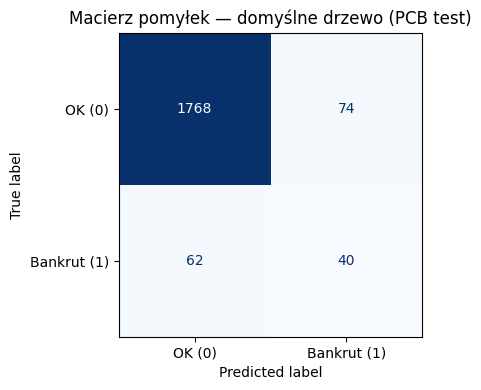

In [157]:
clf_pcb_default = DecisionTreeClassifier()
clf_pcb_default.fit(X_pcb_train, y_pcb_train)

y_pcb_train_pred = clf_pcb_default.predict(X_pcb_train)
y_pcb_test_pred  = clf_pcb_default.predict(X_pcb_test)

print(f'Głębokość: {clf_pcb_default.get_depth()}, Liście: {clf_pcb_default.get_n_leaves()}')
print()
print('{:<15} {:>8} {:>8}'.format('Metryka', 'Train', 'Test'))
print('-' * 35)
for name, tr, te in [
    ('Accuracy',  accuracy_score(y_pcb_train, y_pcb_train_pred),
                  accuracy_score(y_pcb_test,  y_pcb_test_pred)),
    ('Precision', precision_score(y_pcb_train, y_pcb_train_pred, zero_division=0),
                  precision_score(y_pcb_test,  y_pcb_test_pred,  zero_division=0)),
    ('Recall',    recall_score(y_pcb_train, y_pcb_train_pred, zero_division=0),
                  recall_score(y_pcb_test,  y_pcb_test_pred,  zero_division=0)),
    ('F1',        f1_score(y_pcb_train, y_pcb_train_pred, zero_division=0),
                  f1_score(y_pcb_test,  y_pcb_test_pred,  zero_division=0)),
]:
    print('{:<15} {:>8.4f} {:>8.4f}'.format(name, tr, te))

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_pcb_test, y_pcb_test_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['OK (0)', 'Bankrut (1)'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Macierz pomyłek — domyślne drzewo (PCB test)')
plt.tight_layout()
plt.show()

### 5.3 Wpływ parametru `max_depth` na wyniki (PCB)

max_depth sweep (PCB):   0%|          | 0/49 [00:00<?, ?it/s]

Drzewo nasycone przy max_depth=32 (rzeczywista głębokość=31), przerywam sweep.
Najlepsza głębokość (wg CV recall): max_depth=28, CV recall=0.4038


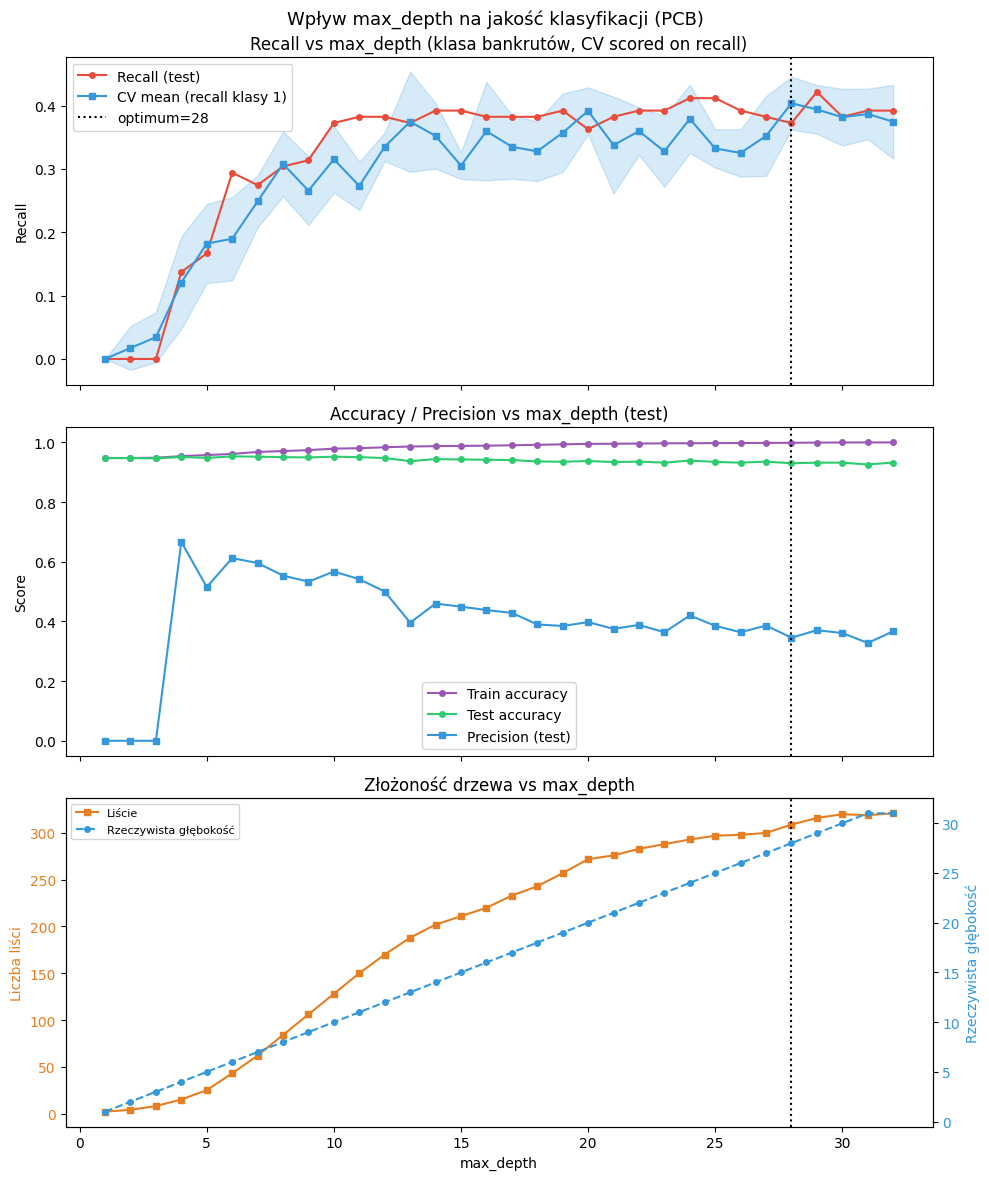

In [165]:
depths = list(range(1, 50))
depth_results_pcb = []

skf = StratifiedKFold(n_splits=5, shuffle=True)

for d in tqdm(depths, desc='max_depth sweep (PCB)'):
    clf = DecisionTreeClassifier(max_depth=d)
    clf.fit(X_pcb_train, y_pcb_train)
    yp_tr = clf.predict(X_pcb_train)
    yp_te = clf.predict(X_pcb_test)
    cv_scores = cross_val_score(clf, X_pcb_train, y_pcb_train, cv=skf, scoring='recall')
    
    actual_depth = clf.get_depth()
    depth_results_pcb.append({
        'max_depth':    d,
        'actual_depth': actual_depth,
        'train_acc':    accuracy_score(y_pcb_train, yp_tr),
        'test_acc':     accuracy_score(y_pcb_test,  yp_te),
        'cv_mean':      cv_scores.mean(),
        'cv_std':       cv_scores.std(),
        'test_prec':    precision_score(y_pcb_test, yp_te, zero_division=0),
        'test_rec':     recall_score(y_pcb_test,    yp_te, zero_division=0),
        'n_leaves':     clf.get_n_leaves(),
    })
    
    if actual_depth < d:
        print(f'Drzewo nasycone przy max_depth={d} (rzeczywista głębokość={actual_depth}), przerywam sweep.')
        break

df_depth_pcb = pd.DataFrame(depth_results_pcb).set_index('max_depth')
best_depth_pcb = int(df_depth_pcb['cv_mean'].idxmax())
print(f'Najlepsza głębokość (wg CV recall): max_depth={best_depth_pcb}, CV recall={df_depth_pcb.loc[best_depth_pcb, "cv_mean"]:.4f}')
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# 1) Recall bankrutów + CV
axes[0].plot(df_depth_pcb.index, df_depth_pcb['test_rec'], color='#e74c3c', marker='o', markersize=4, label='Recall (test)')
axes[0].plot(df_depth_pcb.index, df_depth_pcb['cv_mean'],  color='#3498db', marker='s', markersize=4, label='CV mean (recall klasy 1)')
axes[0].fill_between(df_depth_pcb.index,
                     df_depth_pcb['cv_mean'] - df_depth_pcb['cv_std'],
                     df_depth_pcb['cv_mean'] + df_depth_pcb['cv_std'],
                     alpha=0.2, color='#3498db')
axes[0].axvline(best_depth_pcb, color='black', linestyle=':', label=f'optimum={best_depth_pcb}')
axes[0].set_ylabel('Recall')
axes[0].set_title('Recall vs max_depth (klasa bankrutów, CV scored on recall)')
axes[0].legend()

# 2) Accuracy + Precision
axes[1].plot(df_depth_pcb.index, df_depth_pcb['train_acc'],  color='#9b59b6', marker='o', markersize=4, label='Train accuracy')
axes[1].plot(df_depth_pcb.index, df_depth_pcb['test_acc'],   color='#2ecc71', marker='o', markersize=4, label='Test accuracy')
axes[1].plot(df_depth_pcb.index, df_depth_pcb['test_prec'],  color='#3498db', marker='s', markersize=4, label='Precision (test)')
axes[1].axvline(best_depth_pcb, color='black', linestyle=':')
axes[1].set_ylabel('Score')
axes[1].set_title('Accuracy / Precision vs max_depth (test)')
axes[1].legend()

# 3) Złożoność + rzeczywista głębokość
axes[2].plot(df_depth_pcb.index, df_depth_pcb['n_leaves'], color='#e67e22', marker='s', markersize=4, label='Liście')
axes[2].axvline(best_depth_pcb, color='black', linestyle=':')
axes[2].set_ylabel('Liczba liści', color='#e67e22')
axes[2].tick_params(axis='y', labelcolor='#e67e22')
axes[2].set_xlabel('max_depth')
axes[2].set_title('Złożoność drzewa vs max_depth')

ax_act = axes[2].twinx()
ax_act.plot(df_depth_pcb.index, df_depth_pcb['actual_depth'], color='#3498db', marker='o', markersize=4, linestyle='--', label='Rzeczywista głębokość')
ax_act.set_ylabel('Rzeczywista głębokość', color='#3498db')
ax_act.tick_params(axis='y', labelcolor='#3498db')

lines1, labels1 = axes[2].get_legend_handles_labels()
lines2, labels2 = ax_act.get_legend_handles_labels()
axes[2].legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.suptitle('Wpływ max_depth na jakość klasyfikacji (PCB)', fontsize=13)
plt.tight_layout()
plt.show()

### 5.4 `min_samples_leaf` — minimalna liczba próbek w liściu (PCB)

min_samples_leaf sweep (PCB):   0%|          | 0/99 [00:00<?, ?it/s]

Najlepsze min_samples_leaf (wg CV recall): 2, CV recall=0.3498


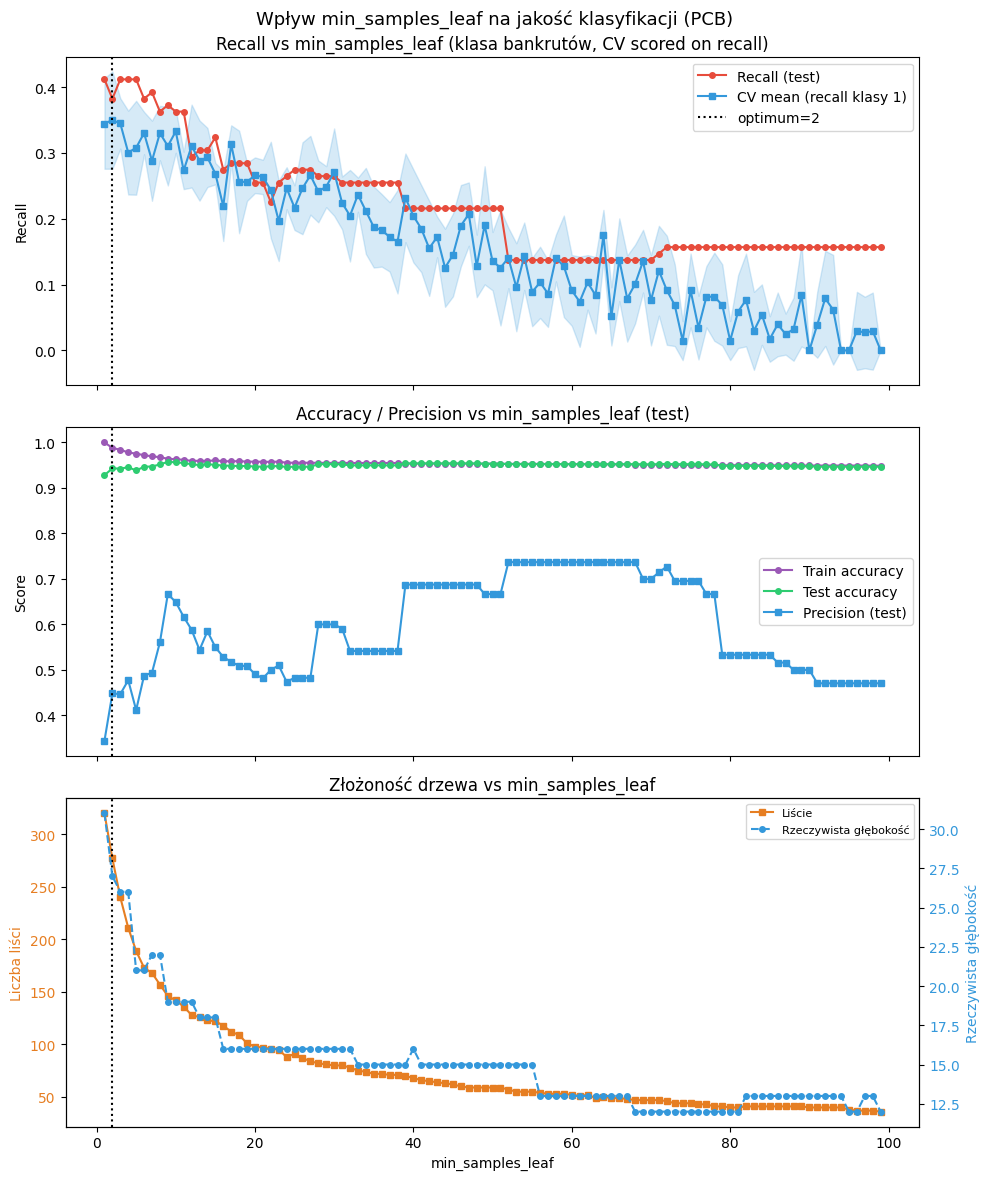

In [167]:
min_samples_values = list(range(1, 100))
leaf_results_pcb = []

skf = StratifiedKFold(n_splits=5, shuffle=True)

for ms in tqdm(min_samples_values, desc='min_samples_leaf sweep (PCB)'):
    clf = DecisionTreeClassifier(min_samples_leaf=ms)
    clf.fit(X_pcb_train, y_pcb_train)
    yp_tr = clf.predict(X_pcb_train)
    yp_te = clf.predict(X_pcb_test)
    cv_scores = cross_val_score(clf, X_pcb_train, y_pcb_train, cv=skf, scoring='recall')
    
    leaf_results_pcb.append({
        'min_samples_leaf': ms,
        'actual_depth':     clf.get_depth(),
        'train_acc':        accuracy_score(y_pcb_train, yp_tr),
        'test_acc':         accuracy_score(y_pcb_test,  yp_te),
        'cv_mean':          cv_scores.mean(),
        'cv_std':           cv_scores.std(),
        'test_prec':        precision_score(y_pcb_test, yp_te, zero_division=0),
        'test_rec':         recall_score(y_pcb_test,    yp_te, zero_division=0),
        'n_leaves':         clf.get_n_leaves(),
    })

df_leaf_pcb = pd.DataFrame(leaf_results_pcb).set_index('min_samples_leaf')
best_ms_pcb = int(df_leaf_pcb['cv_mean'].idxmax())
print(f'Najlepsze min_samples_leaf (wg CV recall): {best_ms_pcb}, CV recall={df_leaf_pcb.loc[best_ms_pcb, "cv_mean"]:.4f}')

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# 1) Recall + CV
axes[0].plot(df_leaf_pcb.index, df_leaf_pcb['test_rec'], color='#e74c3c', marker='o', markersize=4, label='Recall (test)')
axes[0].plot(df_leaf_pcb.index, df_leaf_pcb['cv_mean'],  color='#3498db', marker='s', markersize=4, label='CV mean (recall klasy 1)')
axes[0].fill_between(df_leaf_pcb.index,
                     df_leaf_pcb['cv_mean'] - df_leaf_pcb['cv_std'],
                     df_leaf_pcb['cv_mean'] + df_leaf_pcb['cv_std'],
                     alpha=0.2, color='#3498db')
axes[0].axvline(best_ms_pcb, color='black', linestyle=':', label=f'optimum={best_ms_pcb}')
axes[0].set_ylabel('Recall')
axes[0].set_title('Recall vs min_samples_leaf (klasa bankrutów, CV scored on recall)')
axes[0].legend()

# 2) Accuracy + Precision
axes[1].plot(df_leaf_pcb.index, df_leaf_pcb['train_acc'], color='#9b59b6', marker='o', markersize=4, label='Train accuracy')
axes[1].plot(df_leaf_pcb.index, df_leaf_pcb['test_acc'],  color='#2ecc71', marker='o', markersize=4, label='Test accuracy')
axes[1].plot(df_leaf_pcb.index, df_leaf_pcb['test_prec'], color='#3498db', marker='s', markersize=4, label='Precision (test)')
axes[1].axvline(best_ms_pcb, color='black', linestyle=':')
axes[1].set_ylabel('Score')
axes[1].set_title('Accuracy / Precision vs min_samples_leaf (test)')
axes[1].legend()

# 3) Złożoność + rzeczywista głębokość
axes[2].plot(df_leaf_pcb.index, df_leaf_pcb['n_leaves'], color='#e67e22', marker='s', markersize=4, label='Liście')
axes[2].axvline(best_ms_pcb, color='black', linestyle=':')
axes[2].set_ylabel('Liczba liści', color='#e67e22')
axes[2].tick_params(axis='y', labelcolor='#e67e22')
axes[2].set_xlabel('min_samples_leaf')
axes[2].set_title('Złożoność drzewa vs min_samples_leaf')

ax_act = axes[2].twinx()
ax_act.plot(df_leaf_pcb.index, df_leaf_pcb['actual_depth'], color='#3498db', marker='o', markersize=4, linestyle='--', label='Rzeczywista głębokość')
ax_act.set_ylabel('Rzeczywista głębokość', color='#3498db')
ax_act.tick_params(axis='y', labelcolor='#3498db')

lines1, labels1 = axes[2].get_legend_handles_labels()
lines2, labels2 = ax_act.get_legend_handles_labels()
axes[2].legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.suptitle('Wpływ min_samples_leaf na jakość klasyfikacji (PCB)', fontsize=13)
plt.tight_layout()
plt.show()

### 5.5 Pruning drzewa — `ccp_alpha` (PCB)

Liczba kroków pruning path: 137
Zakres ccp_alpha: [0.000000, 0.002803]


ccp_alpha sweep (PCB):   0%|          | 0/137 [00:00<?, ?it/s]

Najlepsza ccp_alpha (wg CV recall): 0.000129, CV recall=0.4016
Wynikowe drzewo: głębokość=30, liście=259


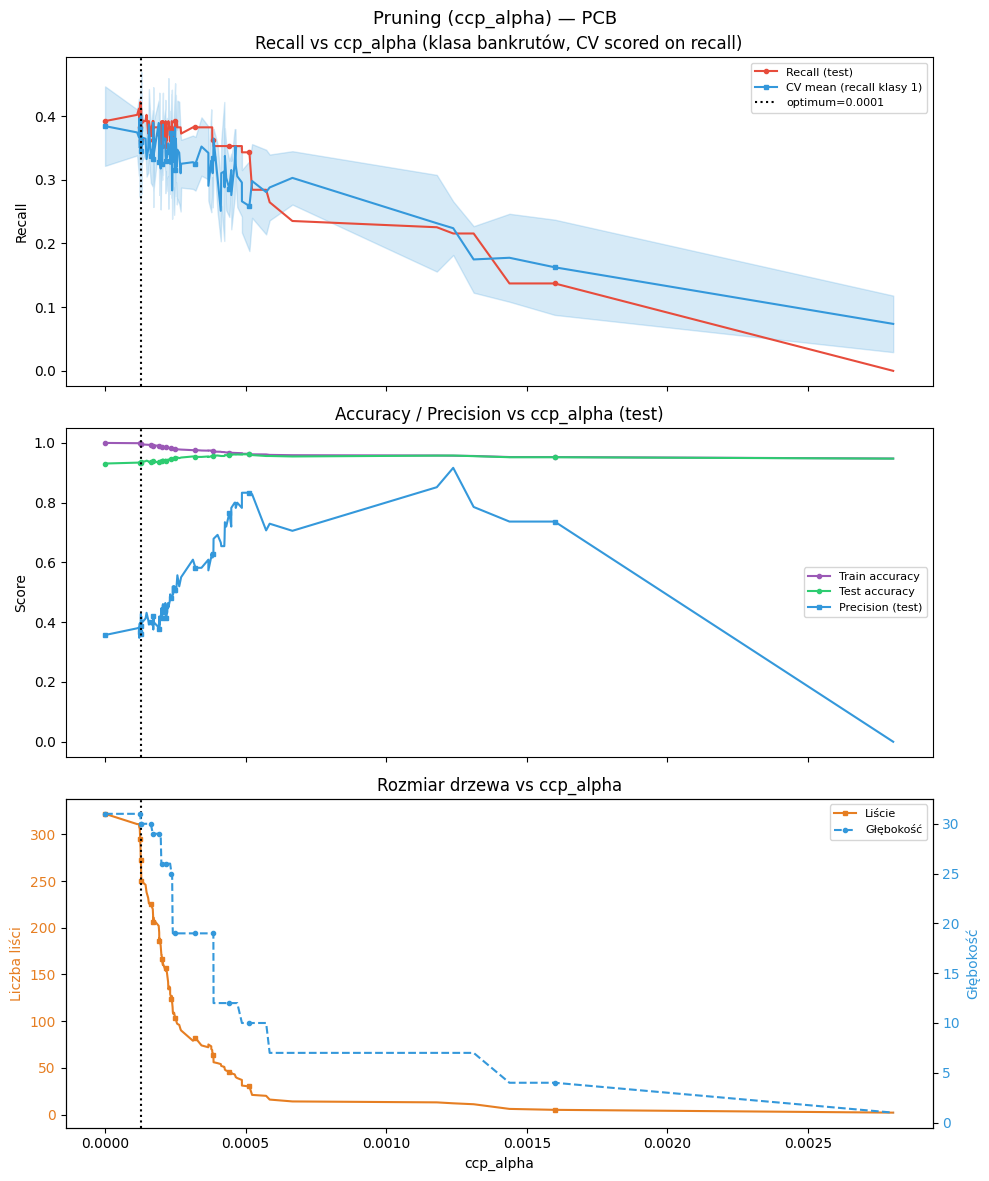

In [ ]:
path = DecisionTreeClassifier().cost_complexity_pruning_path(X_pcb_train, y_pcb_train)
ccp_candidates = path.ccp_alphas[:-1]
step = max(1, len(ccp_candidates) // 8)
ccp_grid_pcb = [0.0] + list(ccp_candidates[::step])

skf = StratifiedKFold(n_splits=5, shuffle=True)

print(f'Liczba kroków pruning path: {len(ccp_candidates)}')
print(f'Zakres ccp_alpha: [{ccp_candidates.min():.6f}, {ccp_candidates.max():.6f}]')

alpha_results_pcb = []
for alpha in tqdm(ccp_candidates, desc='ccp_alpha sweep (PCB)'):
    clf = DecisionTreeClassifier(ccp_alpha=alpha)
    clf.fit(X_pcb_train, y_pcb_train)
    yp_tr = clf.predict(X_pcb_train)
    yp_te = clf.predict(X_pcb_test)
    cv_scores = cross_val_score(clf, X_pcb_train, y_pcb_train, cv=skf, scoring='recall')
    
    alpha_results_pcb.append({
        'ccp_alpha':  alpha,
        'train_acc':  accuracy_score(y_pcb_train, yp_tr),
        'test_acc':   accuracy_score(y_pcb_test,  yp_te),
        'cv_mean':    cv_scores.mean(),
        'cv_std':     cv_scores.std(),
        'test_prec':  precision_score(y_pcb_test, yp_te, zero_division=0),
        'test_rec':   recall_score(y_pcb_test,    yp_te, zero_division=0),
        'n_leaves':   clf.get_n_leaves(),
        'depth':      clf.get_depth(),
    })

df_alpha_pcb = pd.DataFrame(alpha_results_pcb)
best_alpha_idx_pcb = df_alpha_pcb['cv_mean'].idxmax()
best_row_pcb       = df_alpha_pcb.loc[best_alpha_idx_pcb]
best_alpha_pcb     = float(best_row_pcb['ccp_alpha'])

print(f'Najlepsza ccp_alpha (wg CV recall): {best_alpha_pcb:.6f}, CV recall={best_row_pcb["cv_mean"]:.4f}')
print(f'Wynikowe drzewo: głębokość={int(best_row_pcb["depth"])}, liście={int(best_row_pcb["n_leaves"])}')

n_points  = len(df_alpha_pcb)
markevery = max(1, n_points // 15)

fig, axes = plt.subplots(3, 1, figsize=(10, 20), sharex=True)

# 1) Recall + CV
axes[0].plot(df_alpha_pcb['ccp_alpha'], df_alpha_pcb['test_rec'], color='#e74c3c', linewidth=1.5, marker='o', markersize=3, markevery=markevery, label='Recall (test)')
axes[0].plot(df_alpha_pcb['ccp_alpha'], df_alpha_pcb['cv_mean'],  color='#3498db', linewidth=1.5, marker='s', markersize=3, markevery=markevery, label='CV mean (recall klasy 1)')
axes[0].fill_between(df_alpha_pcb['ccp_alpha'],
                     df_alpha_pcb['cv_mean'] - df_alpha_pcb['cv_std'],
                     df_alpha_pcb['cv_mean'] + df_alpha_pcb['cv_std'],
                     alpha=0.2, color='#3498db')
axes[0].axvline(best_alpha_pcb, color='black', linestyle=':', label=f'optimum={best_alpha_pcb:.4f}')
axes[0].set_ylabel('Recall')
axes[0].set_title('Recall vs ccp_alpha (klasa bankrutów, CV scored on recall)')
axes[0].legend(fontsize=8)

# 2) Accuracy + Precision
axes[1].plot(df_alpha_pcb['ccp_alpha'], df_alpha_pcb['train_acc'], color='#9b59b6', linewidth=1.5, marker='o', markersize=3, markevery=markevery, label='Train accuracy')
axes[1].plot(df_alpha_pcb['ccp_alpha'], df_alpha_pcb['test_acc'],  color='#2ecc71', linewidth=1.5, marker='o', markersize=3, markevery=markevery, label='Test accuracy')
axes[1].plot(df_alpha_pcb['ccp_alpha'], df_alpha_pcb['test_prec'], color='#3498db', linewidth=1.5, marker='s', markersize=3, markevery=markevery, label='Precision (test)')
axes[1].axvline(best_alpha_pcb, color='black', linestyle=':')
axes[1].set_ylabel('Score')
axes[1].set_title('Accuracy / Precision vs ccp_alpha (test)')
axes[1].legend(fontsize=8)

# 3) Rozmiar drzewa
ax_leaves = axes[2]
ax_depth  = ax_leaves.twinx()
ax_leaves.plot(df_alpha_pcb['ccp_alpha'], df_alpha_pcb['n_leaves'], color='#e67e22', linewidth=1.5, marker='s', markersize=3, markevery=markevery, label='Liście')
ax_depth.plot(df_alpha_pcb['ccp_alpha'],  df_alpha_pcb['depth'],    color='#3498db', linewidth=1.5, marker='o', markersize=3, markevery=markevery, linestyle='--', label='Głębokość')
ax_leaves.axvline(best_alpha_pcb, color='black', linestyle=':')
ax_leaves.set_xlabel('ccp_alpha')
ax_leaves.set_ylabel('Liczba liści', color='#e67e22')
ax_depth.set_ylabel('Głębokość', color='#3498db')
ax_leaves.tick_params(axis='y', labelcolor='#e67e22')
ax_depth.tick_params(axis='y', labelcolor='#3498db')
lines1, labels1 = ax_leaves.get_legend_handles_labels()
lines2, labels2 = ax_depth.get_legend_handles_labels()
ax_leaves.legend(lines1 + lines2, labels1 + labels2, fontsize=8)
ax_leaves.set_title('Rozmiar drzewa vs ccp_alpha')

plt.suptitle('Pruning (ccp_alpha) — PCB', fontsize=13)
plt.tight_layout()
plt.show()

KFold: CV recall=0.2955 ± 0.0235
  Wyniki foldów: [0.295 0.316 0.278 0.326 0.262]
StratifiedKFold: CV recall=0.2957 ± 0.0454
  Wyniki foldów: [0.284 0.37  0.247 0.321 0.256]

--- Globalne metryki (test) ---
Metryka                      KFold    StratifiedKFold
-------------------------------------------------------
Accuracy                    0.9501             0.9496
Precision                   0.5362             0.5278
Recall                      0.3627             0.3725


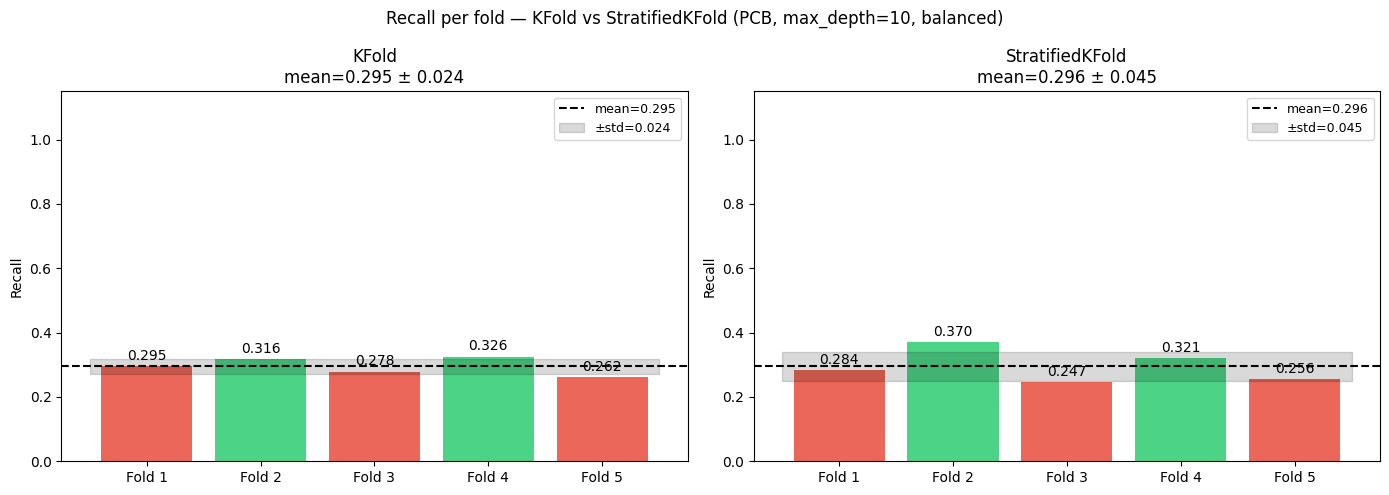

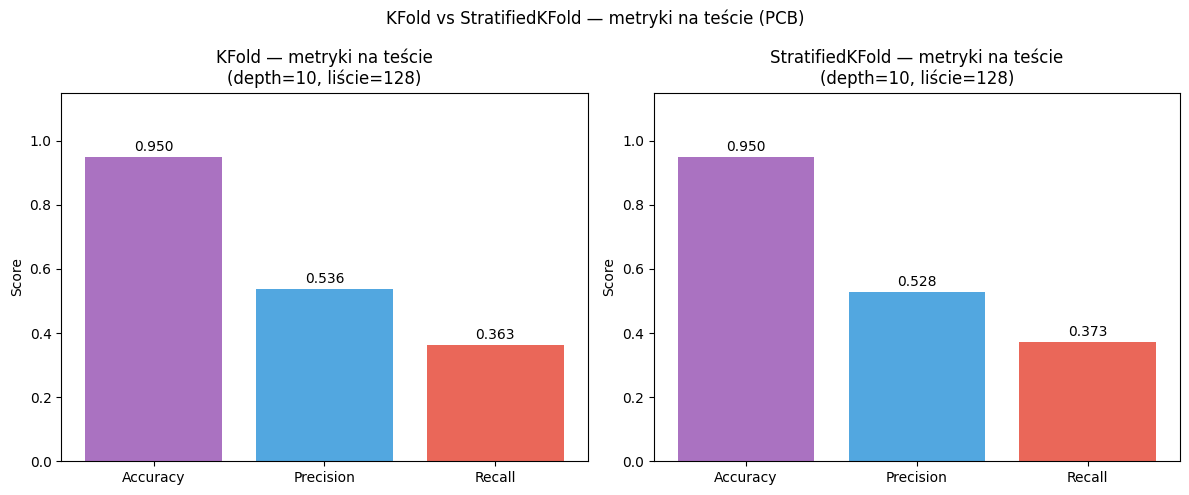

In [183]:
kf  = KFold(n_splits=5, shuffle=True)
skf = StratifiedKFold(n_splits=5, shuffle=True)

results_per_cv_pcb = {}
for cv_name, cv in [('KFold', kf), ('StratifiedKFold', skf)]:
    clf = DecisionTreeClassifier(max_depth=10)
    scores = cross_val_score(clf, X_pcb_train, y_pcb_train, cv=cv, scoring='recall')
    
    clf_final = DecisionTreeClassifier(max_depth=10)
    clf_final.fit(X_pcb_train, y_pcb_train)
    yp = clf_final.predict(X_pcb_test)
    
    results_per_cv_pcb[cv_name] = {
        'cv_scores': scores,
        'cv_mean':   scores.mean(),
        'cv_std':    scores.std(),
        'clf':       clf_final,
        'y_pred':    yp,
    }
    print(f'{cv_name}: CV recall={scores.mean():.4f} ± {scores.std():.4f}')
    print(f'  Wyniki foldów: {np.round(scores, 3)}')

# --- globalne metryki ---
print('\n--- Globalne metryki (test) ---')
print(f'{"Metryka":<15}', end='')
for cv_name in results_per_cv_pcb:
    print(f' {cv_name:>18}', end='')
print()
print('-' * 55)
for metric_name, fn, kw in [
    ('Accuracy',  accuracy_score,  {}),
    ('Precision', precision_score, {'zero_division': 0}),
    ('Recall',    recall_score,    {'zero_division': 0}),
]:
    print(f'{metric_name:<15}', end='')
    for res in results_per_cv_pcb.values():
        val = fn(y_pcb_test, res['y_pred'], **kw)
        print(f' {val:>18.4f}', end='')
    print()

# --- wyniki foldów ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (cv_name, res) in zip(axes, results_per_cv_pcb.items()):
    fold_labels = [f'Fold {i+1}' for i in range(5)]
    colors = ['#e74c3c' if s < res['cv_mean'] else '#2ecc71' for s in res['cv_scores']]
    bars = ax.bar(fold_labels, res['cv_scores'], color=colors, alpha=0.85)
    for bar, val in zip(bars, res['cv_scores']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)
    ax.axhline(res['cv_mean'], color='black', linestyle='--', linewidth=1.5, label=f'mean={res["cv_mean"]:.3f}')
    ax.fill_between([-0.5, 4.5],
                    res['cv_mean'] - res['cv_std'],
                    res['cv_mean'] + res['cv_std'],
                    alpha=0.15, color='black', label=f'±std={res["cv_std"]:.3f}')
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Recall')
    ax.set_title(f'{cv_name}\nmean={res["cv_mean"]:.3f} ± {res["cv_std"]:.3f}')
    ax.legend(fontsize=9)

plt.suptitle('Recall per fold — KFold vs StratifiedKFold (PCB, max_depth=10, balanced)', fontsize=12)
plt.tight_layout()
plt.show()

# --- metryki na teście ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (cv_name, res) in zip(axes, results_per_cv_pcb.items()):
    metrics = ['Accuracy', 'Precision', 'Recall']
    vals = [
        accuracy_score(y_pcb_test,  res['y_pred']),
        precision_score(y_pcb_test, res['y_pred'], zero_division=0),
        recall_score(y_pcb_test,    res['y_pred'], zero_division=0),
    ]
    colors = ['#9b59b6', '#3498db', '#e74c3c']
    bars = ax.bar(metrics, vals, color=colors, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Score')
    ax.set_title(f'{cv_name} — metryki na teście\n(depth={res["clf"].get_depth()}, liście={res["clf"].get_n_leaves()})')

plt.suptitle('KFold vs StratifiedKFold — metryki na teście (PCB)', fontsize=12)
plt.tight_layout()
plt.show()

### 5.3 Wpływ parametru `class_weight`

class_weight:   0%|          | 0/6 [00:00<?, ?it/s]

,Accuracy,Precision,Recall,F1,Głębokość,Liście
class_weight,,,,,,
None,0.9522,0.5652,0.3824,0.4561,10,128
balanced,0.8693,0.1780,0.4118,0.2485,10,167
"{0:1, 1:5}",0.9156,0.2786,0.3824,0.3223,10,177
"{0:1, 1:20}",0.8555,0.1597,0.4118,0.2301,10,141
"{0:1, 1:50}",0.7459,0.1157,0.5784,0.1928,10,100
"{0:1, 1:95}",0.6734,0.1075,0.7157,0.1869,10,67


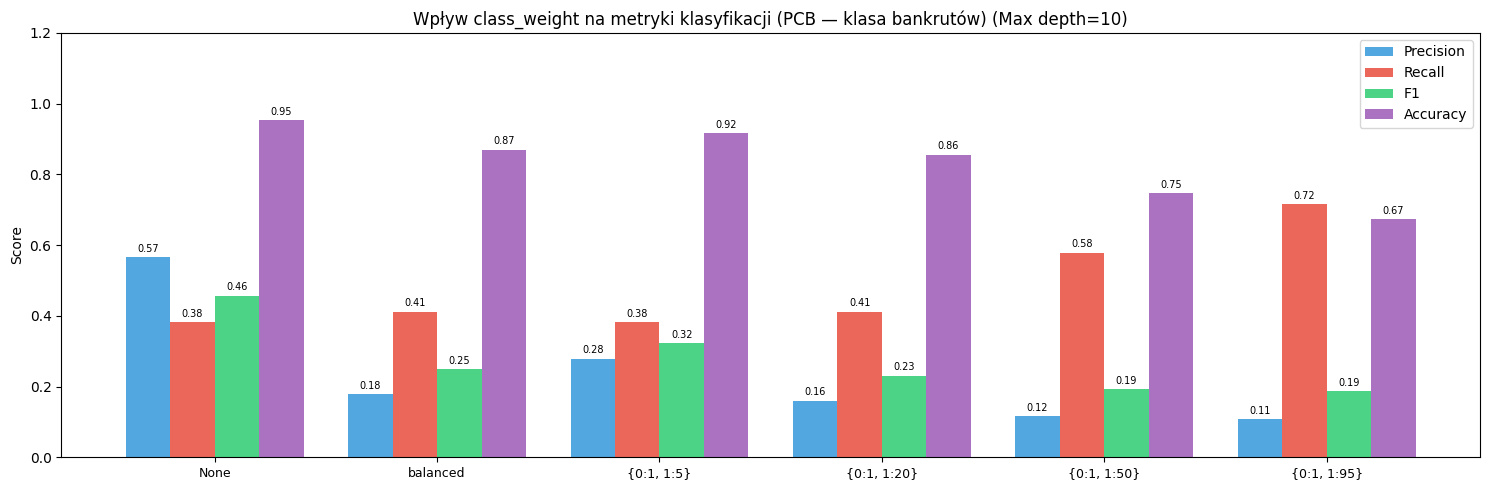

In [181]:
class_weight_variants = [
    ('None',        None),
    ('balanced',    'balanced'),
    ('{0:1, 1:5}',  {0: 1, 1: 5}),
    ('{0:1, 1:20}', {0: 1, 1: 20}),
    ('{0:1, 1:50}', {0: 1, 1: 50}),
    ('{0:1, 1:95}', {0: 1, 1: 95}),
]

cw_results = []
for name, cw in tqdm(class_weight_variants, desc='class_weight'):
    clf = DecisionTreeClassifier(class_weight=cw, max_depth=10)
    clf.fit(X_pcb_train, y_pcb_train)
    yp = clf.predict(X_pcb_test)
    cw_results.append({
        'class_weight': name,
        'Accuracy':  accuracy_score(y_pcb_test, yp),
        'Precision': precision_score(y_pcb_test, yp, zero_division=0),
        'Recall':    recall_score(y_pcb_test,    yp, zero_division=0),
        'F1':        f1_score(y_pcb_test,        yp, zero_division=0),
        'Głębokość': clf.get_depth(),
        'Liście':    clf.get_n_leaves(),
    })

df_cw = pd.DataFrame(cw_results).set_index('class_weight')
display(df_cw.round(4))

fig, ax = plt.subplots(figsize=(15, 5))
x = np.arange(len(df_cw))
width = 0.2
metrics_colors = [('Precision', '#3498db'), ('Recall', '#e74c3c'), ('F1', '#2ecc71'), ('Accuracy', '#9b59b6')]
offsets = [-1.5, -0.5, 0.5, 1.5]

for (metric, color), offset in zip(metrics_colors, offsets):
    bars = ax.bar(x + offset * width, df_cw[metric], width, label=metric, color=color, alpha=0.85)
    for bar in bars:
        if bar.get_height() > 0.02:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(df_cw.index, fontsize=9)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.2)
ax.set_title('Wpływ class_weight na metryki klasyfikacji (PCB — klasa bankrutów) (Max depth=10)')
ax.legend()
plt.tight_layout()
plt.show()